In [1]:
%pip install numpy pandas torch seaborn matplotlib tqdm nibabel

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import nibabel as nib
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import LinearSegmentedColormap

# Seaborn styling for research publications
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.2)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 9

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

Using device: cpu


In [3]:
# Project structure
PROJECT_ROOT = Path('..') 
DATA_ROOT = PROJECT_ROOT / 'BraTS2020_ValidationData' / 'MICCAI_BraTS2020_ValidationData'
OUTPUT_DIR = Path('/home/claude/MLFM/results')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Modalities
MODALITIES = ['t1', 't2', 'flair', 't1ce']
MODALITY_NAMES = {'t1': 'T1', 't2': 'T2', 'flair': 'FLAIR', 't1ce': 'T1CE'}

# Hyperparameters
PATCH_SIZE = 64
LATENT_DIM_ZA = 64  # Anatomy latent dimension
LATENT_DIM_ZM = 32  # Modality latent dimension
BATCH_SIZE = 8
NUM_EPOCHS = 30
LEARNING_RATE = 1e-4

print(f"Project Root: {PROJECT_ROOT.resolve()}")
print(f"Data Root: {DATA_ROOT.resolve()}")
print(f"Output Dir: {OUTPUT_DIR.resolve()}")
print(f"\nPatch Size: {PATCH_SIZE}x{PATCH_SIZE}x{PATCH_SIZE}")
print(f"Za Dimension: {LATENT_DIM_ZA}")
print(f"Zm Dimension: {LATENT_DIM_ZM}")

Project Root: C:\Users\arnav\Desktop\MedBIND3D\MedBIND3D
Data Root: C:\Users\arnav\Desktop\MedBIND3D\MedBIND3D\BraTS2020_ValidationData\MICCAI_BraTS2020_ValidationData
Output Dir: C:\home\claude\MLFM\results

Patch Size: 64x64x64
Za Dimension: 64
Zm Dimension: 32


In [4]:
class BraTS2020Dataset(Dataset):
    """BraTS2020 Dataset for multimodal brain MRI"""
    
    def __init__(self, data_root, modalities, patch_size=64, num_patches_per_volume=10):
        self.data_root = Path(data_root)
        self.modalities = modalities
        self.patch_size = patch_size
        self.num_patches_per_volume = num_patches_per_volume
        
        # Find all patient directories
        self.patient_dirs = sorted([d for d in self.data_root.iterdir() if d.is_dir()])
        print(f"Found {len(self.patient_dirs)} patients")
        
        # Pre-extract patches from all volumes
        self.patches = []
        self.patient_ids = []
        self.modality_labels = []
        
        print("\nExtracting patches from all volumes...")
        for patient_dir in tqdm(self.patient_dirs[:20], desc="Loading patients"):  # Use first 20 for speed
            patient_id = patient_dir.name
            
            # Load all modalities for this patient
            volumes = {}
            for mod in self.modalities:
                file_path = patient_dir / f"{patient_id}_{mod}.nii"
                if file_path.exists():
                    vol = nib.load(str(file_path)).get_fdata()
                    # Z-score normalization
                    vol = (vol - vol.mean()) / (vol.std() + 1e-8)
                    volumes[mod] = vol
            
            if len(volumes) == len(self.modalities):
                # Extract random patches from brain region
                vol_shape = list(volumes.values())[0].shape
                
                for _ in range(self.num_patches_per_volume):
                    # Random location (avoid edges)
                    x = np.random.randint(20, vol_shape[0] - self.patch_size - 20)
                    y = np.random.randint(20, vol_shape[1] - self.patch_size - 20)
                    z = np.random.randint(20, vol_shape[2] - self.patch_size - 20)
                    
                    # Extract patches from all modalities
                    for mod in self.modalities:
                        patch = volumes[mod][x:x+self.patch_size, 
                                            y:y+self.patch_size, 
                                            z:z+self.patch_size]
                        
                        # Skip if patch is mostly background
                        if patch.std() > 0.1:
                            self.patches.append(patch.copy())
                            self.patient_ids.append(patient_id)
                            self.modality_labels.append(mod)
        
        self.patches = np.array(self.patches)
        print(f"\nTotal patches extracted: {len(self.patches)}")
        print(f"Patch shape: {self.patches[0].shape}")
        
    def __len__(self):
        return len(self.patches)
    
    def __getitem__(self, idx):
        patch = self.patches[idx]
        modality = self.modality_labels[idx]
        patient_id = self.patient_ids[idx]
        
        # Convert to tensor with channel dimension
        patch_tensor = torch.FloatTensor(patch).unsqueeze(0)  # (1, D, H, W)
        
        # One-hot encode modality
        modality_idx = MODALITIES.index(modality)
        modality_onehot = torch.zeros(len(MODALITIES))
        modality_onehot[modality_idx] = 1.0
        
        return {
            'patch': patch_tensor,
            'modality': modality_onehot,
            'modality_name': modality,
            'patient_id': patient_id
        }

In [5]:
# Create dataset and dataloader
dataset = BraTS2020Dataset(
    data_root=DATA_ROOT,
    modalities=MODALITIES,
    patch_size=PATCH_SIZE,
    num_patches_per_volume=10
)

dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,  # Set to 0 for Windows compatibility
    pin_memory=True if torch.cuda.is_available() else False
)

print(f"\nDataLoader created with {len(dataloader)} batches")

Found 125 patients

Extracting patches from all volumes...


Loading patients: 100%|██████████| 20/20 [00:14<00:00,  1.42it/s]



Total patches extracted: 800
Patch shape: (64, 64, 64)

DataLoader created with 100 batches


In [6]:
class LOFEAnatomyEncoder(nn.Module):
    """Linear Operator Factor Extraction for anatomy latent Za"""
    
    def __init__(self, input_channels=1, latent_dim=64):
        super().__init__()
        
        # Linear operator convolutions (structure extraction)
        self.conv1 = nn.Conv3d(input_channels, 32, kernel_size=3, stride=2, padding=1)
        self.conv2 = nn.Conv3d(32, 64, kernel_size=3, stride=2, padding=1)
        self.conv3 = nn.Conv3d(64, 128, kernel_size=3, stride=2, padding=1)
        self.conv4 = nn.Conv3d(128, 256, kernel_size=3, stride=2, padding=1)
        
        self.bn1 = nn.BatchNorm3d(32)
        self.bn2 = nn.BatchNorm3d(64)
        self.bn3 = nn.BatchNorm3d(128)
        self.bn4 = nn.BatchNorm3d(256)
        
        # Global pooling and latent projection
        self.global_pool = nn.AdaptiveAvgPool3d(1)
        self.fc_za = nn.Linear(256, latent_dim)
        
        # Operator field extraction (for visualization)
        self.operator_field = nn.Conv3d(256, 3, kernel_size=1)  # 3 channels for vector field
        
    def forward(self, x):
        # Extract hierarchical features
        h1 = F.relu(self.bn1(self.conv1(x)))
        h2 = F.relu(self.bn2(self.conv2(h1)))
        h3 = F.relu(self.bn3(self.conv3(h2)))
        h4 = F.relu(self.bn4(self.conv4(h3)))
        
        # Operator field for visualization
        op_field = self.operator_field(h4)
        
        # Global pooling and projection to Za
        pooled = self.global_pool(h4).squeeze(-1).squeeze(-1).squeeze(-1)
        za = self.fc_za(pooled)
        
        return za, op_field

In [7]:
class PKModalityEncoder(nn.Module):
    """Polynomial Kernel Encoder for modality latent Zm"""
    
    def __init__(self, input_channels=1, modality_dim=4, latent_dim=32, poly_degree=3):
        super().__init__()
        self.poly_degree = poly_degree
        
        # Shallow feature extraction (contrast-sensitive)
        self.conv1 = nn.Conv3d(input_channels, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv3d(16, 32, kernel_size=3, padding=1)
        
        self.bn1 = nn.BatchNorm3d(16)
        self.bn2 = nn.BatchNorm3d(32)
        
        # Polynomial kernel layers
        self.poly_layers = nn.ModuleList([
            nn.Linear(32, 32) for _ in range(poly_degree)
        ])
        
        # Modality conditioning
        self.modality_embed = nn.Linear(modality_dim, 32)
        
        # Global pooling and projection to Zm
        self.global_pool = nn.AdaptiveAvgPool3d(1)
        self.fc_zm = nn.Linear(64, latent_dim)  # 32 (features) + 32 (modality)
        
        # Polynomial response surface (for visualization)
        self.response_map = nn.Conv3d(32, 1, kernel_size=1)
        
    def forward(self, x, modality_onehot):
        batch_size = x.shape[0]
        
        # Shallow contrast-sensitive features
        h1 = F.relu(self.bn1(self.conv1(x)))
        h2 = F.relu(self.bn2(self.conv2(h1)))
        
        # Polynomial response surface
        response = torch.sigmoid(self.response_map(h2))
        
        # Global pooling
        pooled = self.global_pool(h2).view(batch_size, -1)
        
        # Apply polynomial kernel transformation
        poly_features = pooled
        for i, poly_layer in enumerate(self.poly_layers):
            poly_features = poly_layer(poly_features)
            if i < len(self.poly_layers) - 1:
                poly_features = torch.pow(poly_features, i + 2)  # x^2, x^3, ...
        
        # Modality embedding
        mod_embed = self.modality_embed(modality_onehot)
        
        # Concatenate and project to Zm
        combined = torch.cat([poly_features, mod_embed], dim=1)
        zm = self.fc_zm(combined)
        
        return zm, response

In [8]:
class TensorReconstructionDecoder(nn.Module):
    """Tensor Reconstruction Decoder combining Za and Zm"""
    
    def __init__(self, za_dim=64, zm_dim=32, output_channels=1):
        super().__init__()
        
        # Combine Za and Zm
        combined_dim = za_dim + zm_dim
        
        # Project to spatial features
        self.fc = nn.Linear(combined_dim, 256 * 4 * 4 * 4)
        
        # Upsampling path
        self.deconv1 = nn.ConvTranspose3d(256, 128, kernel_size=4, stride=2, padding=1)
        self.deconv2 = nn.ConvTranspose3d(128, 64, kernel_size=4, stride=2, padding=1)
        self.deconv3 = nn.ConvTranspose3d(64, 32, kernel_size=4, stride=2, padding=1)
        self.deconv4 = nn.ConvTranspose3d(32, output_channels, kernel_size=4, stride=2, padding=1)
        
        self.bn1 = nn.BatchNorm3d(128)
        self.bn2 = nn.BatchNorm3d(64)
        self.bn3 = nn.BatchNorm3d(32)
        
    def forward(self, za, zm):
        # Combine anatomy and modality latents
        z_combined = torch.cat([za, zm], dim=1)
        
        # Project to spatial volume
        h = self.fc(z_combined)
        h = h.view(h.shape[0], 256, 4, 4, 4)
        
        # Upsample to original resolution
        h = F.relu(self.bn1(self.deconv1(h)))
        h = F.relu(self.bn2(self.deconv2(h)))
        h = F.relu(self.bn3(self.deconv3(h)))
        reconstruction = self.deconv4(h)
        
        return reconstruction

In [9]:
class LOFEPKModel(nn.Module):
    """Complete LOFE-PK factorization model"""
    
    def __init__(self, za_dim=64, zm_dim=32):
        super().__init__()
        
        self.lofe_encoder = LOFEAnatomyEncoder(input_channels=1, latent_dim=za_dim)
        self.pk_encoder = PKModalityEncoder(input_channels=1, modality_dim=4, latent_dim=zm_dim)
        self.decoder = TensorReconstructionDecoder(za_dim=za_dim, zm_dim=zm_dim, output_channels=1)
        
    def forward(self, x, modality_onehot):
        # Extract anatomy latent (modality-invariant)
        za, op_field = self.lofe_encoder(x)
        
        # Extract modality latent (anatomy-invariant)
        zm, response = self.pk_encoder(x, modality_onehot)
        
        # Reconstruct image
        reconstruction = self.decoder(za, zm)
        
        return {
            'reconstruction': reconstruction,
            'za': za,
            'zm': zm,
            'operator_field': op_field,
            'response': response
        }

In [10]:
def reconstruction_loss(recon, target):
    """MSE reconstruction loss"""
    return F.mse_loss(recon, target)

def anatomy_invariance_loss(za_batch, modality_labels):
    """Enforce Za to be invariant across modalities (for same anatomy)"""
    # Group by patient (assuming batch has mixed modalities from same patient)
    # Simple variance-based penalty: Za should have low variance across modalities
    variance = torch.var(za_batch, dim=0).mean()
    return variance

def modality_discrimination_loss(zm_batch, modality_onehot):
    """Enforce Zm to discriminate between modalities"""
    # Zm should be distinct for different modalities
    # Use contrastive loss: maximize separation between different modalities
    
    # Compute pairwise distances in Zm space
    zm_norm = F.normalize(zm_batch, dim=1)
    similarity = torch.mm(zm_norm, zm_norm.t())
    
    # Compute modality similarity
    modality_similarity = torch.mm(modality_onehot, modality_onehot.t())
    
    # Contrastive loss: high similarity for same modality, low for different
    loss = F.mse_loss(similarity, modality_similarity)
    
    return loss

def orthogonality_loss(za, zm):
    """Enforce Za and Zm to be orthogonal (independent)"""
    # Project Zm to Za's dimension using the covariance matrix approach
    # Compute cross-correlation between Za and Zm features
    batch_size = za.shape[0]
    
    # Center the features
    za_centered = za - za.mean(dim=0, keepdim=True)
    zm_centered = zm - zm.mean(dim=0, keepdim=True)
    
    # Compute cross-covariance matrix (za_dim x zm_dim)
    cross_cov = torch.mm(za_centered.t(), zm_centered) / (batch_size - 1)
    
    # Penalize non-zero cross-covariance (want orthogonality)
    # Use Frobenius norm
    ortho_loss = torch.norm(cross_cov, p='fro') / (za.shape[1] * zm.shape[1])
    
    return ortho_loss

def total_loss(outputs, targets, modality_onehot, 
               alpha=1.0, beta=0.1, gamma=0.1, delta=0.05):
    """Combined loss for LOFE-PK training"""
    recon = outputs['reconstruction']
    za = outputs['za']
    zm = outputs['zm']
    
    # Reconstruction loss
    loss_recon = reconstruction_loss(recon, targets)
    
    # Disentanglement losses
    loss_anatomy_inv = anatomy_invariance_loss(za, modality_onehot)
    loss_modality_disc = modality_discrimination_loss(zm, modality_onehot)
    loss_ortho = orthogonality_loss(za, zm)
    
    # Total loss
    loss = (alpha * loss_recon + 
            beta * loss_anatomy_inv + 
            gamma * loss_modality_disc + 
            delta * loss_ortho)
    
    return loss, {
        'loss_recon': loss_recon.item(),
        'loss_anatomy_inv': loss_anatomy_inv.item(),
        'loss_modality_disc': loss_modality_disc.item(),
        'loss_ortho': loss_ortho.item()
    }

In [11]:
# Initialize model
model = LOFEPKModel(za_dim=LATENT_DIM_ZA, zm_dim=LATENT_DIM_ZM).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

print(f"\nModel initialized with {sum(p.numel() for p in model.parameters()):,} parameters")
print(f"Za dimension: {LATENT_DIM_ZA}")
print(f"Zm dimension: {LATENT_DIM_ZM}")


Model initialized with 5,545,061 parameters
Za dimension: 64
Zm dimension: 32


In [12]:
# Training loop
history = {
    'epoch': [],
    'total_loss': [],
    'recon_loss': [],
    'anatomy_inv_loss': [],
    'modality_disc_loss': [],
    'ortho_loss': []
}

print("\n" + "="*80)
print("TRAINING LOFE-PK MODEL")
print("="*80)

for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_losses = {'total': 0, 'recon': 0, 'anatomy_inv': 0, 'modality_disc': 0, 'ortho': 0}
    
    pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")
    for batch in pbar:
        patches = batch['patch'].to(device)
        modality_onehot = batch['modality'].to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(patches, modality_onehot)
        
        # Compute loss (with error handling for dimension mismatch)
        try:
            loss, loss_dict = total_loss(outputs, patches, modality_onehot)
        except RuntimeError as e:
            print(f"\nError in loss computation: {e}")
            print(f"Za shape: {outputs['za'].shape}")
            print(f"Zm shape: {outputs['zm'].shape}")
            raise
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Accumulate losses
        epoch_losses['total'] += loss.item()
        epoch_losses['recon'] += loss_dict['loss_recon']
        epoch_losses['anatomy_inv'] += loss_dict['loss_anatomy_inv']
        epoch_losses['modality_disc'] += loss_dict['loss_modality_disc']
        epoch_losses['ortho'] += loss_dict['loss_ortho']
        
        # Update progress bar
        pbar.set_postfix({
            'Loss': f"{loss.item():.4f}",
            'Recon': f"{loss_dict['loss_recon']:.4f}"
        })
    
    # Average losses
    num_batches = len(dataloader)
    avg_losses = {k: v / num_batches for k, v in epoch_losses.items()}
    
    # Update history
    history['epoch'].append(epoch + 1)
    history['total_loss'].append(avg_losses['total'])
    history['recon_loss'].append(avg_losses['recon'])
    history['anatomy_inv_loss'].append(avg_losses['anatomy_inv'])
    history['modality_disc_loss'].append(avg_losses['modality_disc'])
    history['ortho_loss'].append(avg_losses['ortho'])
    
    # Learning rate scheduling
    scheduler.step()
    
    # Print epoch summary
    print(f"\nEpoch {epoch+1} Summary:")
    print(f"  Total Loss: {avg_losses['total']:.4f}")
    print(f"  Recon Loss: {avg_losses['recon']:.4f}")
    print(f"  Anatomy Inv: {avg_losses['anatomy_inv']:.4f}")
    print(f"  Modality Disc: {avg_losses['modality_disc']:.4f}")
    print(f"  Ortho Loss: {avg_losses['ortho']:.4f}")
    print(f"  LR: {scheduler.get_last_lr()[0]:.6f}")

print("\n" + "="*80)
print("TRAINING COMPLETE")
print("="*80)


TRAINING LOFE-PK MODEL


Epoch 1/30: 100%|██████████| 100/100 [02:00<00:00,  1.20s/it, Loss=1.4539, Recon=1.4486]



Epoch 1 Summary:
  Total Loss: 2.2940
  Recon Loss: 2.2831
  Anatomy Inv: 0.0530
  Modality Disc: 0.0566
  Ortho Loss: 0.0002
  LR: 0.000100


Epoch 2/30: 100%|██████████| 100/100 [01:48<00:00,  1.09s/it, Loss=1.0370, Recon=1.0309]



Epoch 2 Summary:
  Total Loss: 1.1797
  Recon Loss: 1.1745
  Anatomy Inv: 0.0502
  Modality Disc: 0.0017
  Ortho Loss: 0.0002
  LR: 0.000099


...


Epoch 28 Summary:
  Total Loss: 0.5397
  Recon Loss: 0.5385
  Anatomy Inv: 0.0109
  Modality Disc: 0.0004
  Ortho Loss: 0.0001
  LR: 0.000001


Epoch 29/30: 100%|██████████| 100/100 [02:16<00:00,  1.36s/it, Loss=0.4686, Recon=0.4677]



Epoch 29 Summary:
  Total Loss: 0.5335
  Recon Loss: 0.5324
  Anatomy Inv: 0.0108
  Modality Disc: 0.0004
  Ortho Loss: 0.0001
  LR: 0.000000


Epoch 30/30: 100%|██████████| 100/100 [02:09<00:00,  1.29s/it, Loss=0.4257, Recon=0.4243]


Epoch 30 Summary:
  Total Loss: 0.5398
  Recon Loss: 0.5387
  Anatomy Inv: 0.0108
  Modality Disc: 0.0007
  Ortho Loss: 0.0001
  LR: 0.000000

TRAINING COMPLETE


In [13]:
# Extract latent codes for all samples
model.eval()
all_za = []
all_zm = []
all_modalities = []
all_patients = []
all_reconstructions = []
all_originals = []
all_operator_fields = []
all_responses = []

print("\nExtracting latent codes for all samples...")
with torch.no_grad():
    for batch in tqdm(dataloader, desc="Extracting latents"):
        patches = batch['patch'].to(device)
        modality_onehot = batch['modality'].to(device)
        
        # Forward pass
        outputs = model(patches, modality_onehot)
        
        # Store results
        all_za.append(outputs['za'].cpu().numpy())
        all_zm.append(outputs['zm'].cpu().numpy())
        all_reconstructions.append(outputs['reconstruction'].cpu().numpy())
        all_originals.append(patches.cpu().numpy())
        all_operator_fields.append(outputs['operator_field'].cpu().numpy())
        all_responses.append(outputs['response'].cpu().numpy())
        
        all_modalities.extend(batch['modality_name'])
        all_patients.extend(batch['patient_id'])

# Concatenate all results
all_za = np.concatenate(all_za, axis=0)
all_zm = np.concatenate(all_zm, axis=0)
all_reconstructions = np.concatenate(all_reconstructions, axis=0)
all_originals = np.concatenate(all_originals, axis=0)
all_operator_fields = np.concatenate(all_operator_fields, axis=0)
all_responses = np.concatenate(all_responses, axis=0)

print(f"\nExtracted latent codes:")
print(f"  Za shape: {all_za.shape}")
print(f"  Zm shape: {all_zm.shape}")
print(f"  Reconstructions shape: {all_reconstructions.shape}")
print(f"  Operator fields shape: {all_operator_fields.shape}")
print(f"  Response maps shape: {all_responses.shape}")


Extracting latent codes for all samples...


Extracting latents: 100%|██████████| 100/100 [00:34<00:00,  2.87it/s]



Extracted latent codes:
  Za shape: (800, 64)
  Zm shape: (800, 32)
  Reconstructions shape: (800, 1, 64, 64, 64)
  Operator fields shape: (800, 3, 4, 4, 4)
  Response maps shape: (800, 1, 64, 64, 64)


In [14]:
# Save latent codes
np.save(OUTPUT_DIR / 'Za_anatomy_latents.npy', all_za)
np.save(OUTPUT_DIR / 'Zm_modality_latents.npy', all_zm)
np.save(OUTPUT_DIR / 'reconstructions.npy', all_reconstructions)
np.save(OUTPUT_DIR / 'originals.npy', all_originals)
np.save(OUTPUT_DIR / 'operator_fields.npy', all_operator_fields)
np.save(OUTPUT_DIR / 'response_maps.npy', all_responses)

# Save metadata
metadata_df = pd.DataFrame({
    'patient_id': all_patients,
    'modality': all_modalities
})
metadata_df.to_csv(OUTPUT_DIR / 'metadata.csv', index=False)

# Save training history
history_df = pd.DataFrame(history)
history_df.to_csv(OUTPUT_DIR / 'training_history.csv', index=False)

# Save model
torch.save(model.state_dict(), OUTPUT_DIR / 'lofe_pk_model.pth')

print("\n✓ All results saved to:", OUTPUT_DIR.resolve())


✓ All results saved to: C:\home\claude\MLFM\results


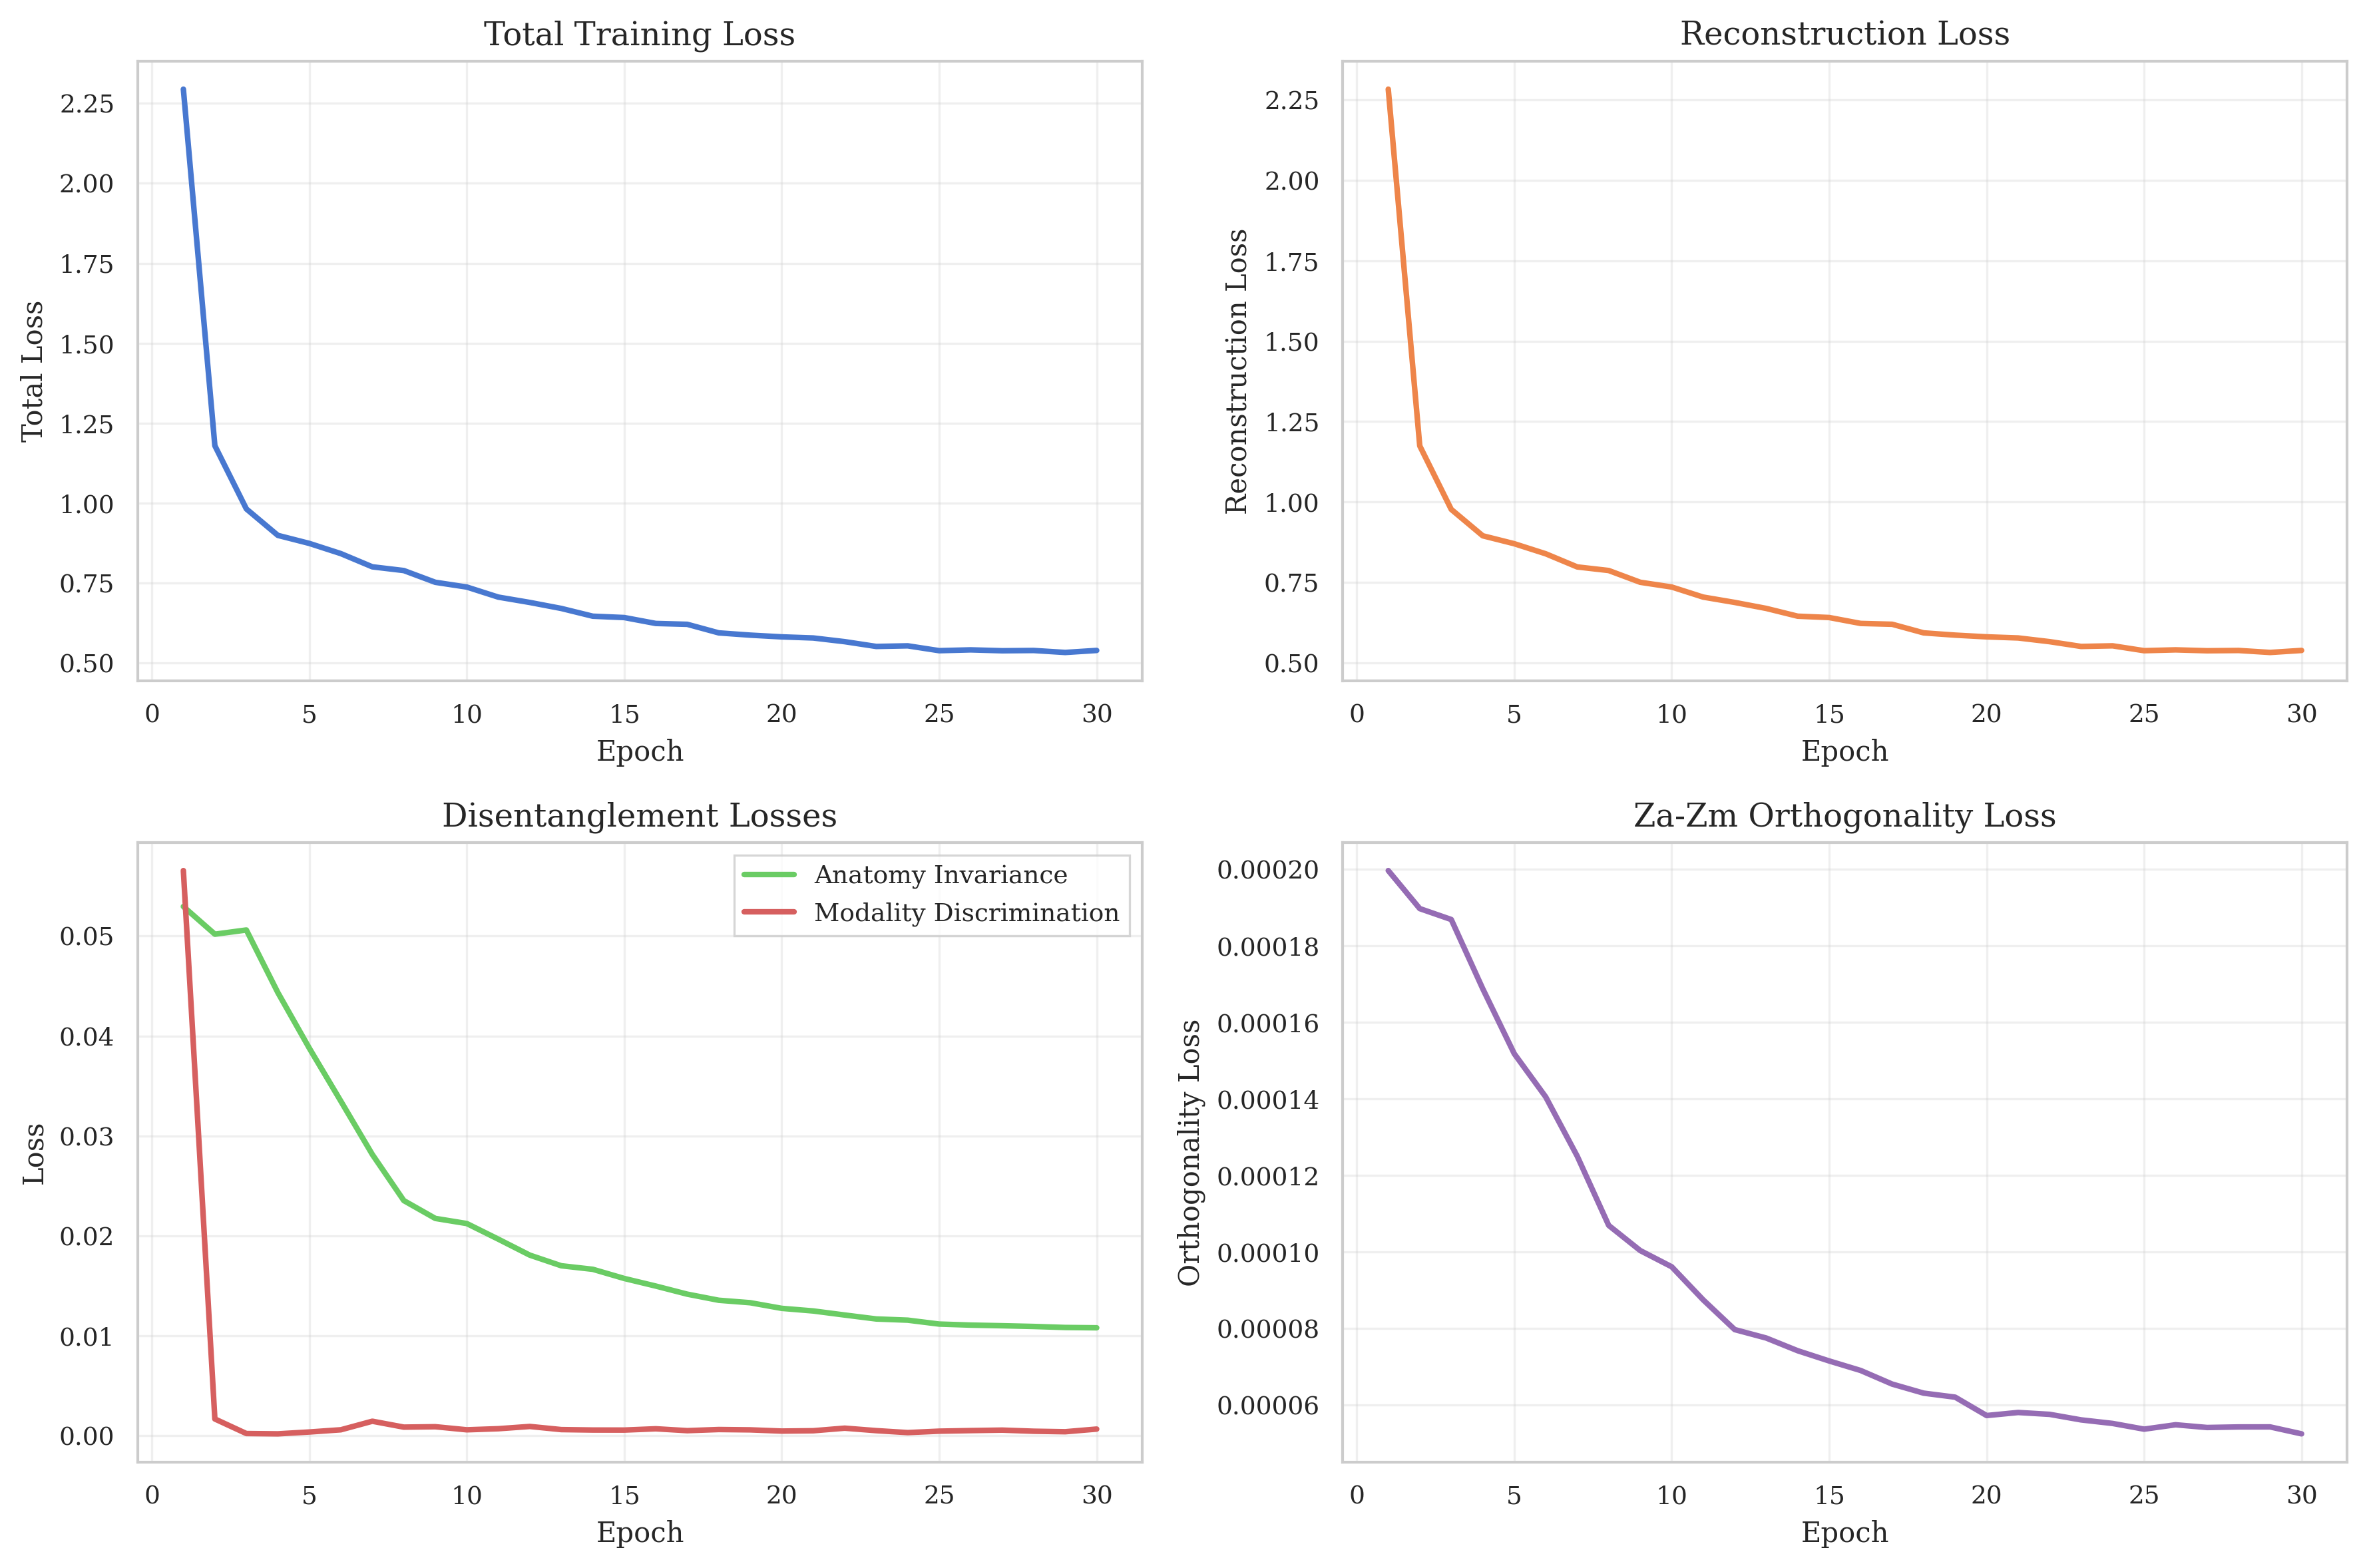

✓ Saved: 01_training_curves.png


In [15]:
# Subtle color palette for research publications
colors = sns.color_palette("muted", 5)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Total loss
axes[0, 0].plot(history['epoch'], history['total_loss'], color=colors[0], linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Total Loss')
axes[0, 0].set_title('Total Training Loss')
axes[0, 0].grid(True, alpha=0.3)

# Reconstruction loss
axes[0, 1].plot(history['epoch'], history['recon_loss'], color=colors[1], linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Reconstruction Loss')
axes[0, 1].set_title('Reconstruction Loss')
axes[0, 1].grid(True, alpha=0.3)

# Disentanglement losses
axes[1, 0].plot(history['epoch'], history['anatomy_inv_loss'], 
                label='Anatomy Invariance', color=colors[2], linewidth=2)
axes[1, 0].plot(history['epoch'], history['modality_disc_loss'], 
                label='Modality Discrimination', color=colors[3], linewidth=2)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].set_title('Disentanglement Losses')
axes[1, 0].legend(frameon=True, fancybox=False)
axes[1, 0].grid(True, alpha=0.3)

# Orthogonality loss
axes[1, 1].plot(history['epoch'], history['ortho_loss'], color=colors[4], linewidth=2)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Orthogonality Loss')
axes[1, 1].set_title('Za-Zm Orthogonality Loss')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '01_training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: 01_training_curves.png")

In [19]:
%pip install scipy

  Using cached scipy-1.16.3-cp312-cp312-win_amd64.whl.metadata (60 kB)
Using cached scipy-1.16.3-cp312-cp312-win_amd64.whl (38.6 MB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


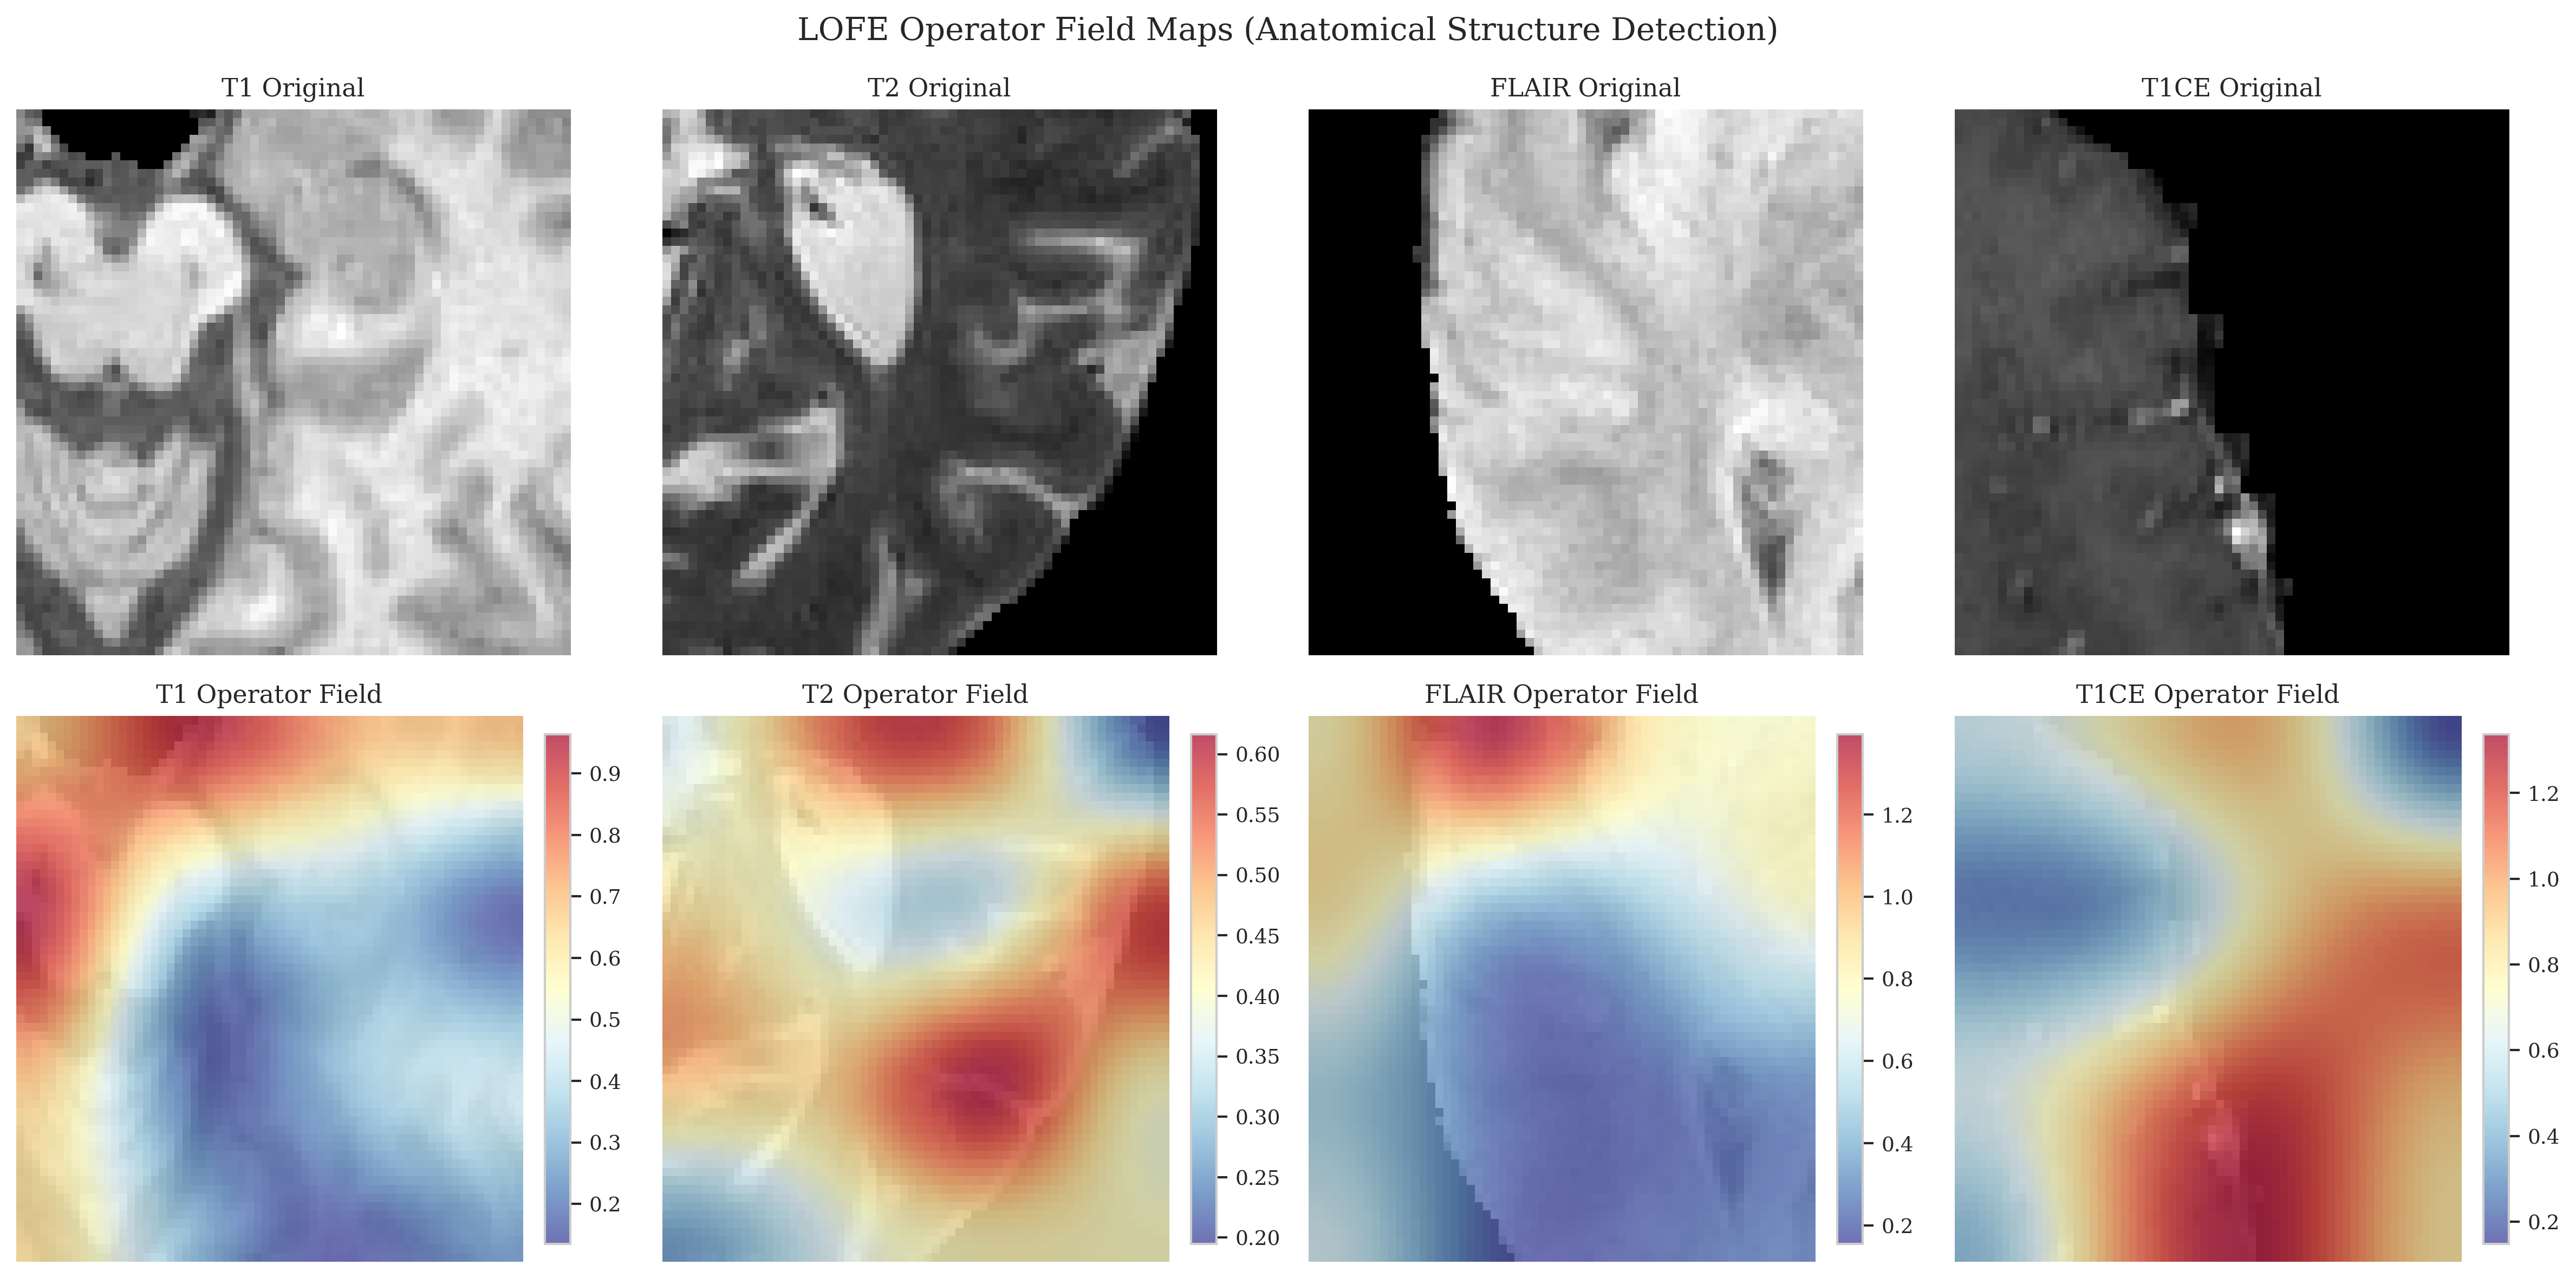

✓ Saved: 02_lofe_operator_fields.png


In [20]:
# Select sample operator fields from different modalities
sample_indices = [np.where(np.array(all_modalities) == mod)[0][0] for mod in MODALITIES]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for idx, mod_idx in enumerate(sample_indices):
    # Get operator field and original image
    op_field = all_operator_fields[mod_idx]  # (3, D, H, W) at low res
    original = all_originals[mod_idx, 0]  # (64, 64, 64) full resolution
    
    # Take central slice
    slice_idx = original.shape[-1] // 2
    original_slice = original[:, :, slice_idx]
    
    # Upsample operator field to match original resolution using interpolation
    from scipy.ndimage import zoom
    
    op_field_slice = op_field[:, op_field.shape[1]//2, :, :]  # (3, H_low, W_low)
    
    # Compute magnitude
    magnitude_low = np.sqrt(np.sum(op_field_slice**2, axis=0))
    
    # Upsample to 64x64
    zoom_factor = original.shape[0] / magnitude_low.shape[0]
    magnitude_high = zoom(magnitude_low, zoom_factor, order=3)  # Cubic interpolation
    
    # Top row: Original images
    axes[0, idx].imshow(original_slice.T, cmap='gray', aspect='auto')
    axes[0, idx].set_title(f'{MODALITY_NAMES[all_modalities[mod_idx]]} Original', fontsize=11)
    axes[0, idx].axis('off')
    
    # Bottom row: Operator field overlaid on image
    axes[1, idx].imshow(original_slice.T, cmap='gray', aspect='auto', alpha=0.6)
    im = axes[1, idx].imshow(magnitude_high.T, cmap='RdYlBu_r', aspect='auto', alpha=0.7)
    axes[1, idx].set_title(f'{MODALITY_NAMES[all_modalities[mod_idx]]} Operator Field', fontsize=11)
    axes[1, idx].axis('off')
    
    # Add colorbar only to bottom row
    plt.colorbar(im, ax=axes[1, idx], fraction=0.046, pad=0.04)

plt.suptitle('LOFE Operator Field Maps (Anatomical Structure Detection)', fontsize=14, y=0.98)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '02_lofe_operator_fields.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: 02_lofe_operator_fields.png")

In [22]:
%pip install scikit-learn

  Using cached scikit_learn-1.7.2-cp312-cp312-win_amd64.whl.metadata (11 kB)
  Using cached joblib-1.5.2-py3-none-any.whl.metadata (5.6 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.7.2-cp312-cp312-win_amd64.whl (8.7 MB)
Using cached joblib-1.5.2-py3-none-any.whl (308 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


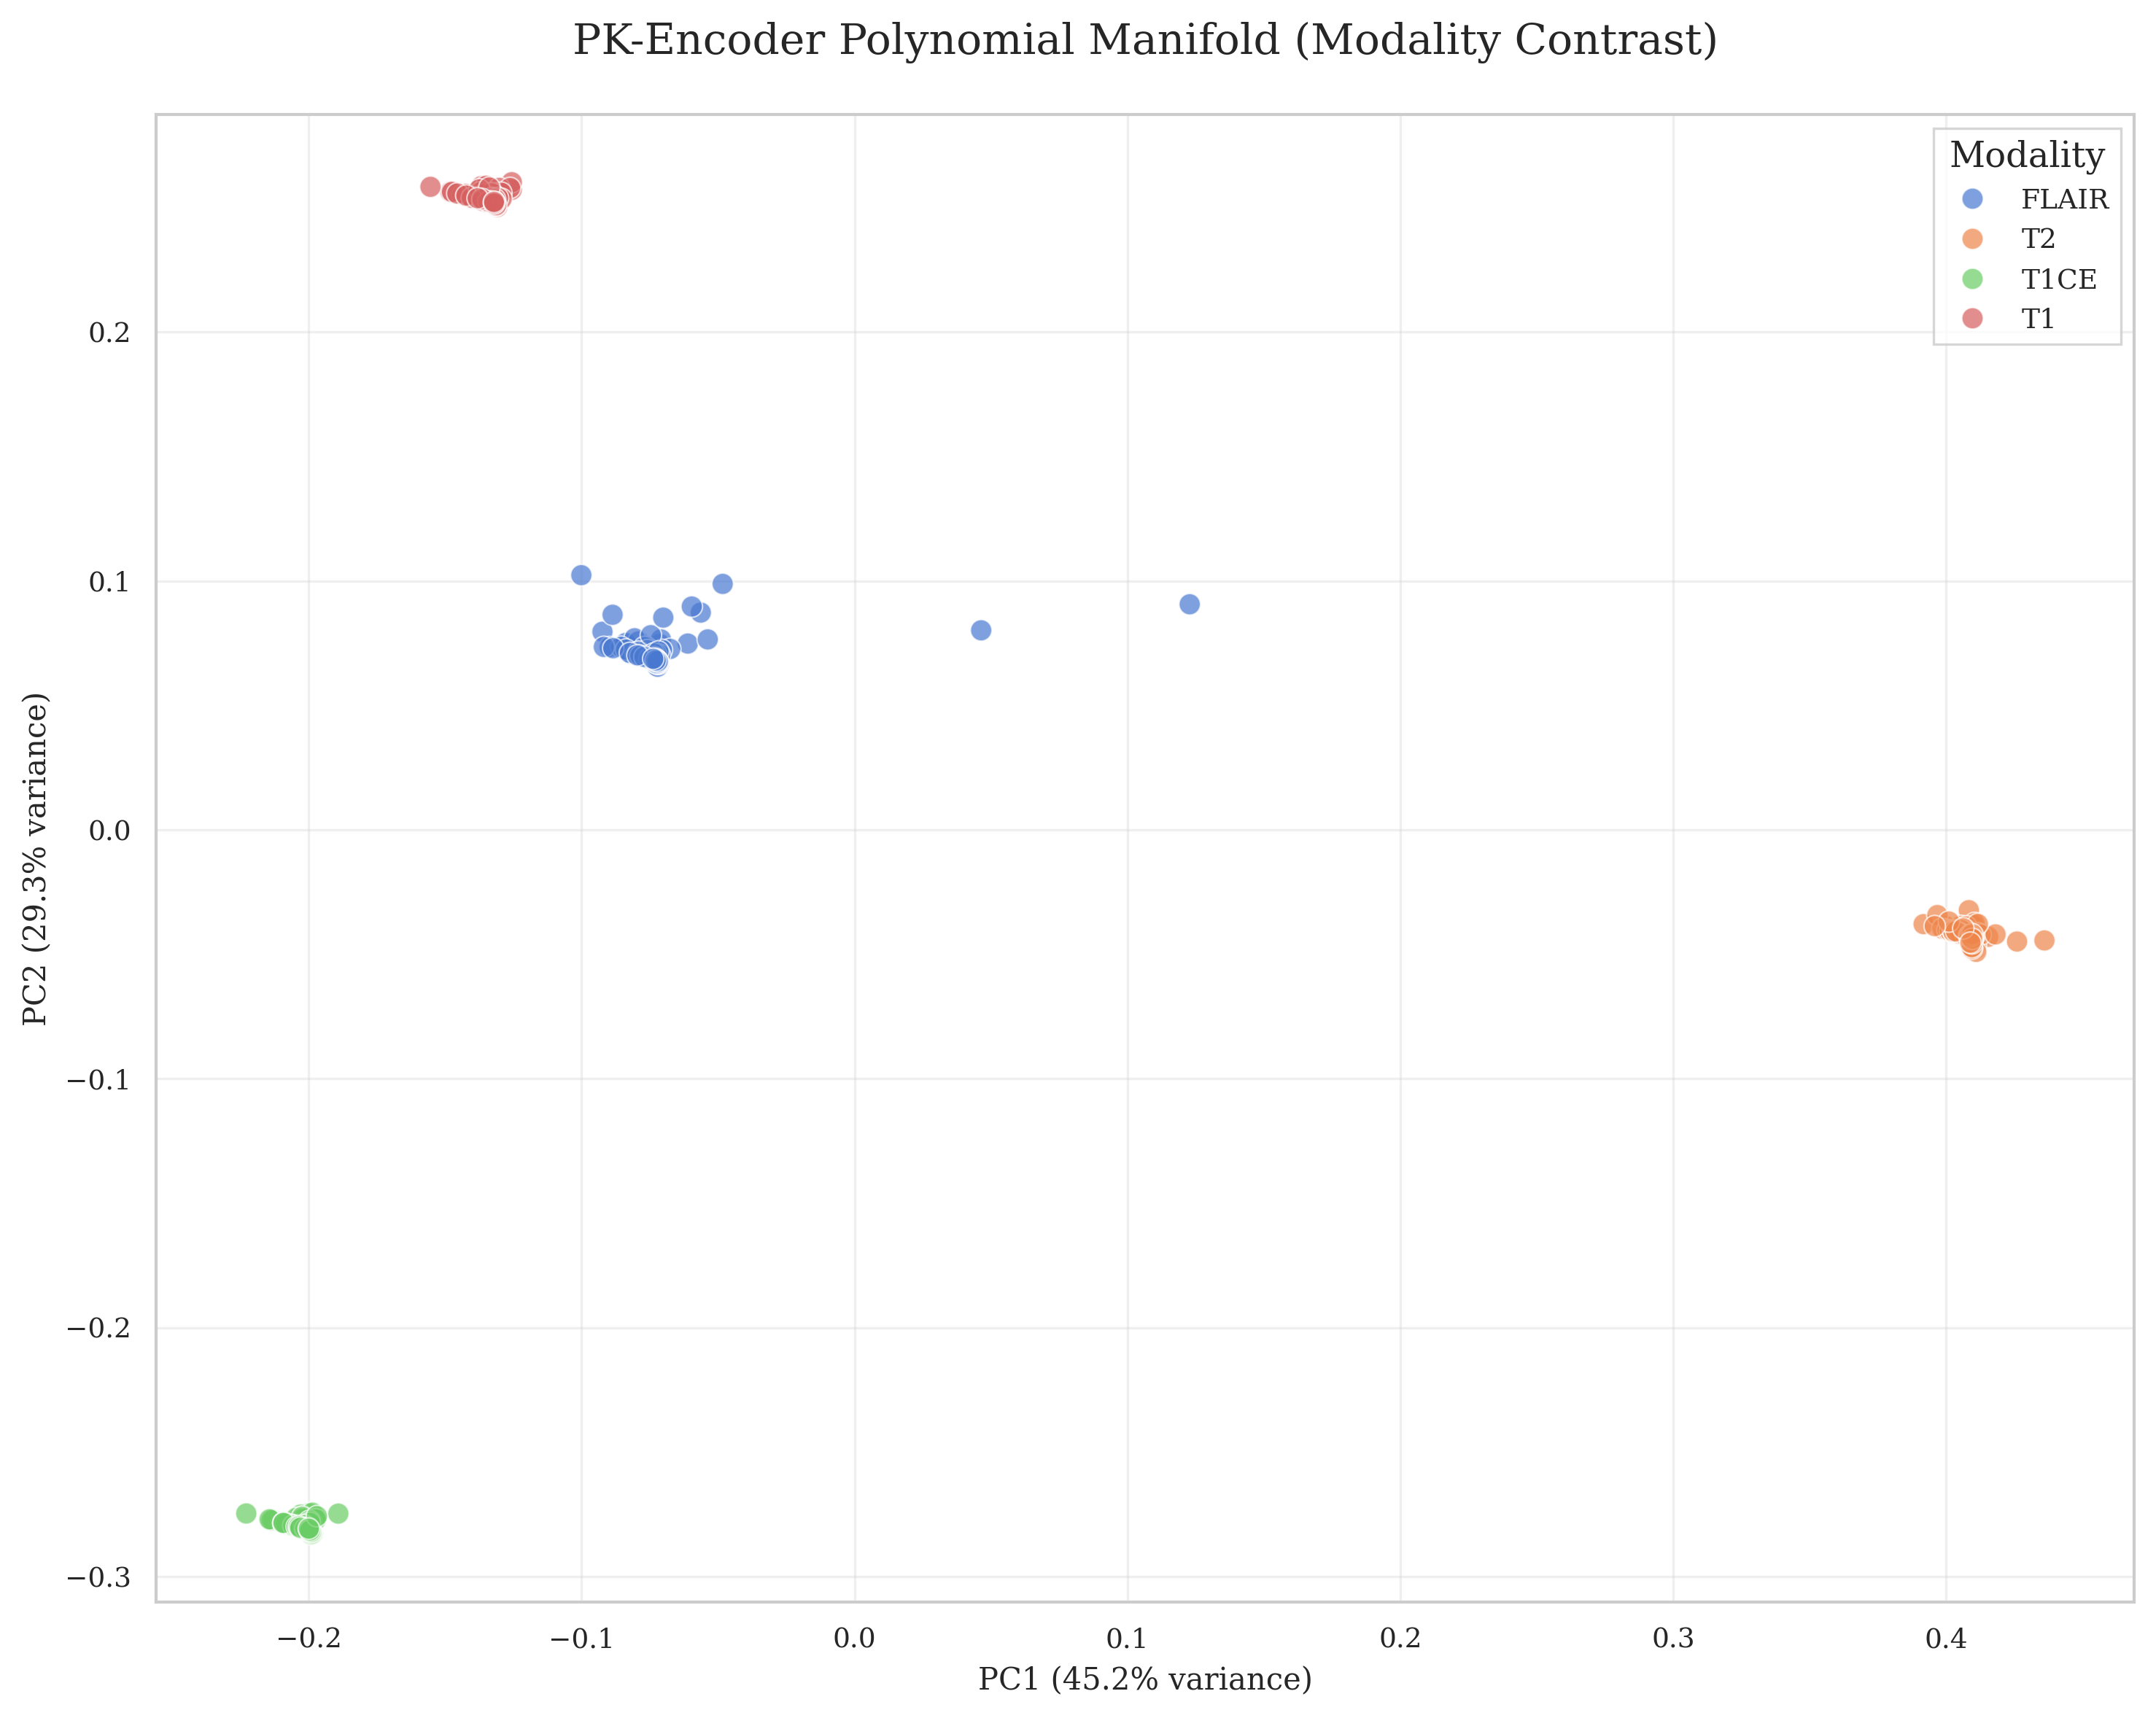

✓ Saved: 03_pk_polynomial_manifold_2d.png


In [23]:
from sklearn.decomposition import PCA

# PCA on Zm
pca = PCA(n_components=2)
zm_2d = pca.fit_transform(all_zm)

# Create DataFrame for plotting
plot_df = pd.DataFrame({
    'PC1': zm_2d[:, 0],
    'PC2': zm_2d[:, 1],
    'Modality': [MODALITY_NAMES[m] for m in all_modalities]
})

# Plot with seaborn
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=plot_df,
    x='PC1',
    y='PC2',
    hue='Modality',
    palette='muted',
    s=50,
    alpha=0.7,
    edgecolor='white',
    linewidth=0.5
)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('PK-Encoder Polynomial Manifold (Modality Contrast)', fontsize=14, pad=20)
plt.legend(title='Modality', frameon=True, fancybox=False)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '03_pk_polynomial_manifold_2d.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: 03_pk_polynomial_manifold_2d.png")

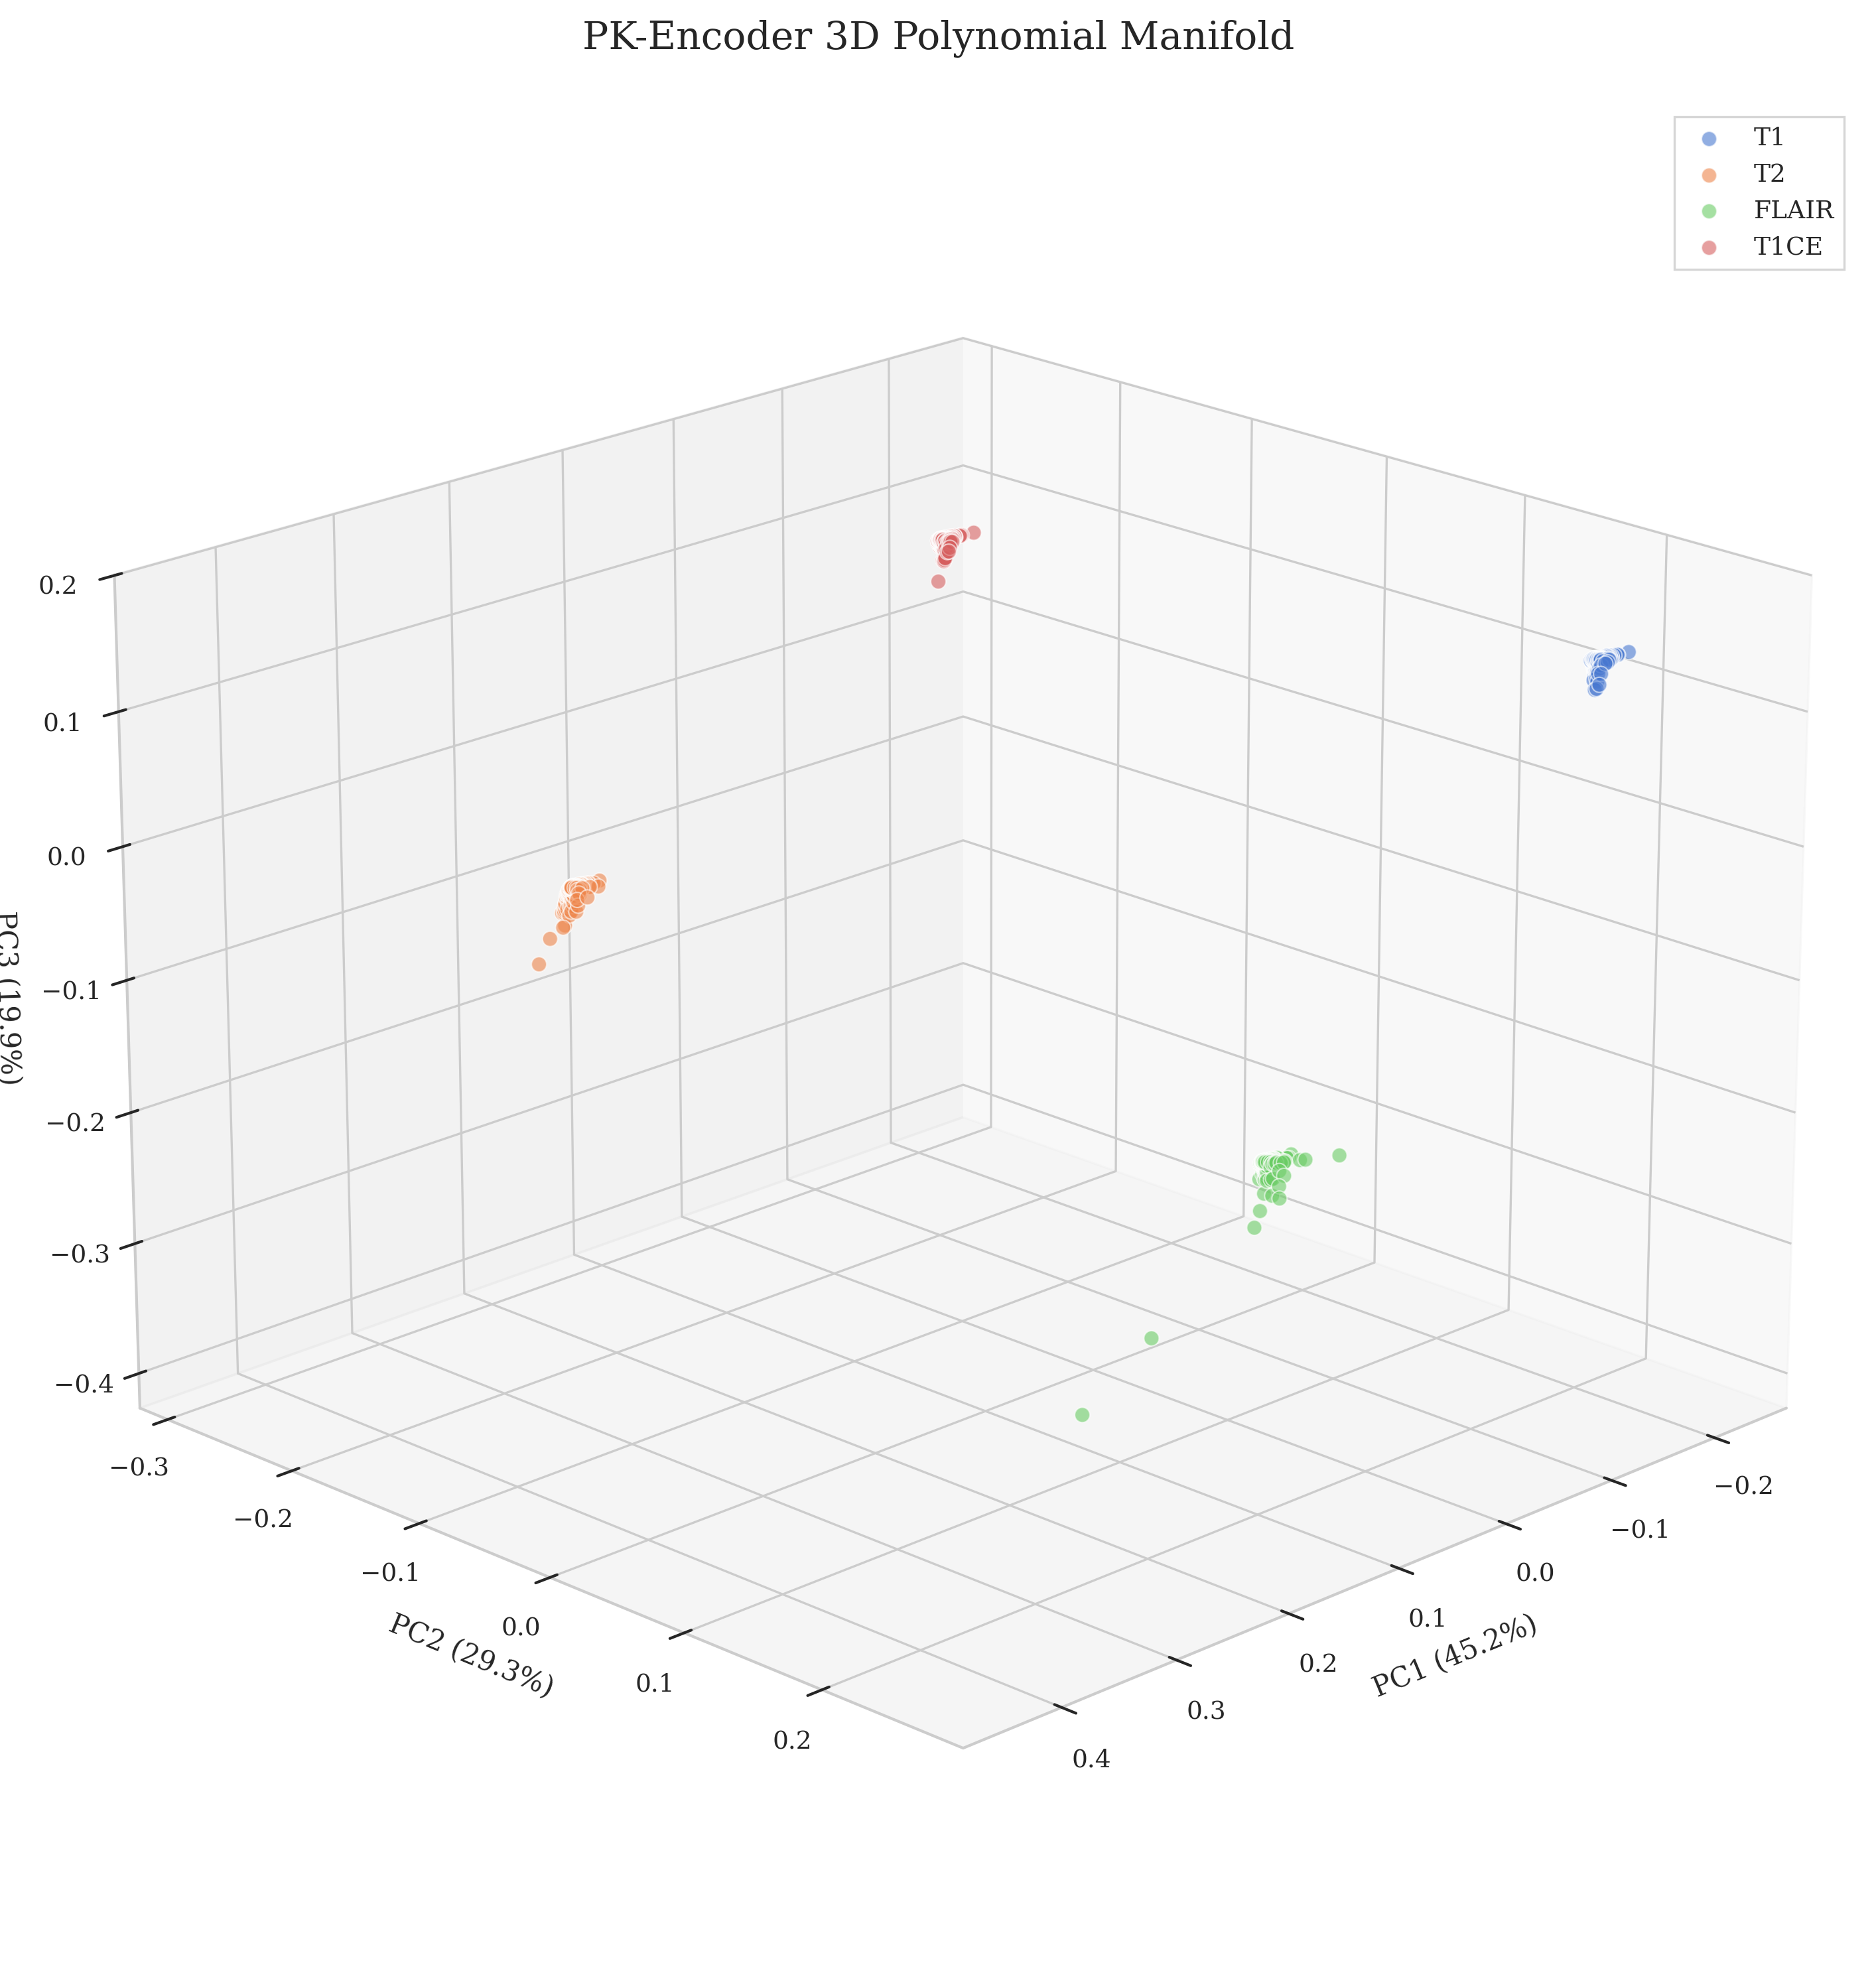

✓ Saved: 04_pk_polynomial_manifold_3d.png


In [24]:
# PCA to 3D
pca_3d = PCA(n_components=3)
zm_3d = pca_3d.fit_transform(all_zm)

# Create 3D scatter plot
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

modality_colors = {'T1': colors[0], 'T2': colors[1], 'FLAIR': colors[2], 'T1CE': colors[3]}

for modality in ['T1', 'T2', 'FLAIR', 'T1CE']:
    mask = np.array([MODALITY_NAMES[m] == modality for m in all_modalities])
    ax.scatter(
        zm_3d[mask, 0],
        zm_3d[mask, 1],
        zm_3d[mask, 2],
        label=modality,
        c=[modality_colors[modality]],
        s=30,
        alpha=0.6,
        edgecolors='white',
        linewidths=0.5
    )

ax.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]*100:.1f}%)')
ax.set_title('PK-Encoder 3D Polynomial Manifold', fontsize=14, pad=20)
ax.legend(frameon=True, fancybox=False)
ax.view_init(elev=20, azim=45)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '04_pk_polynomial_manifold_3d.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: 04_pk_polynomial_manifold_3d.png")

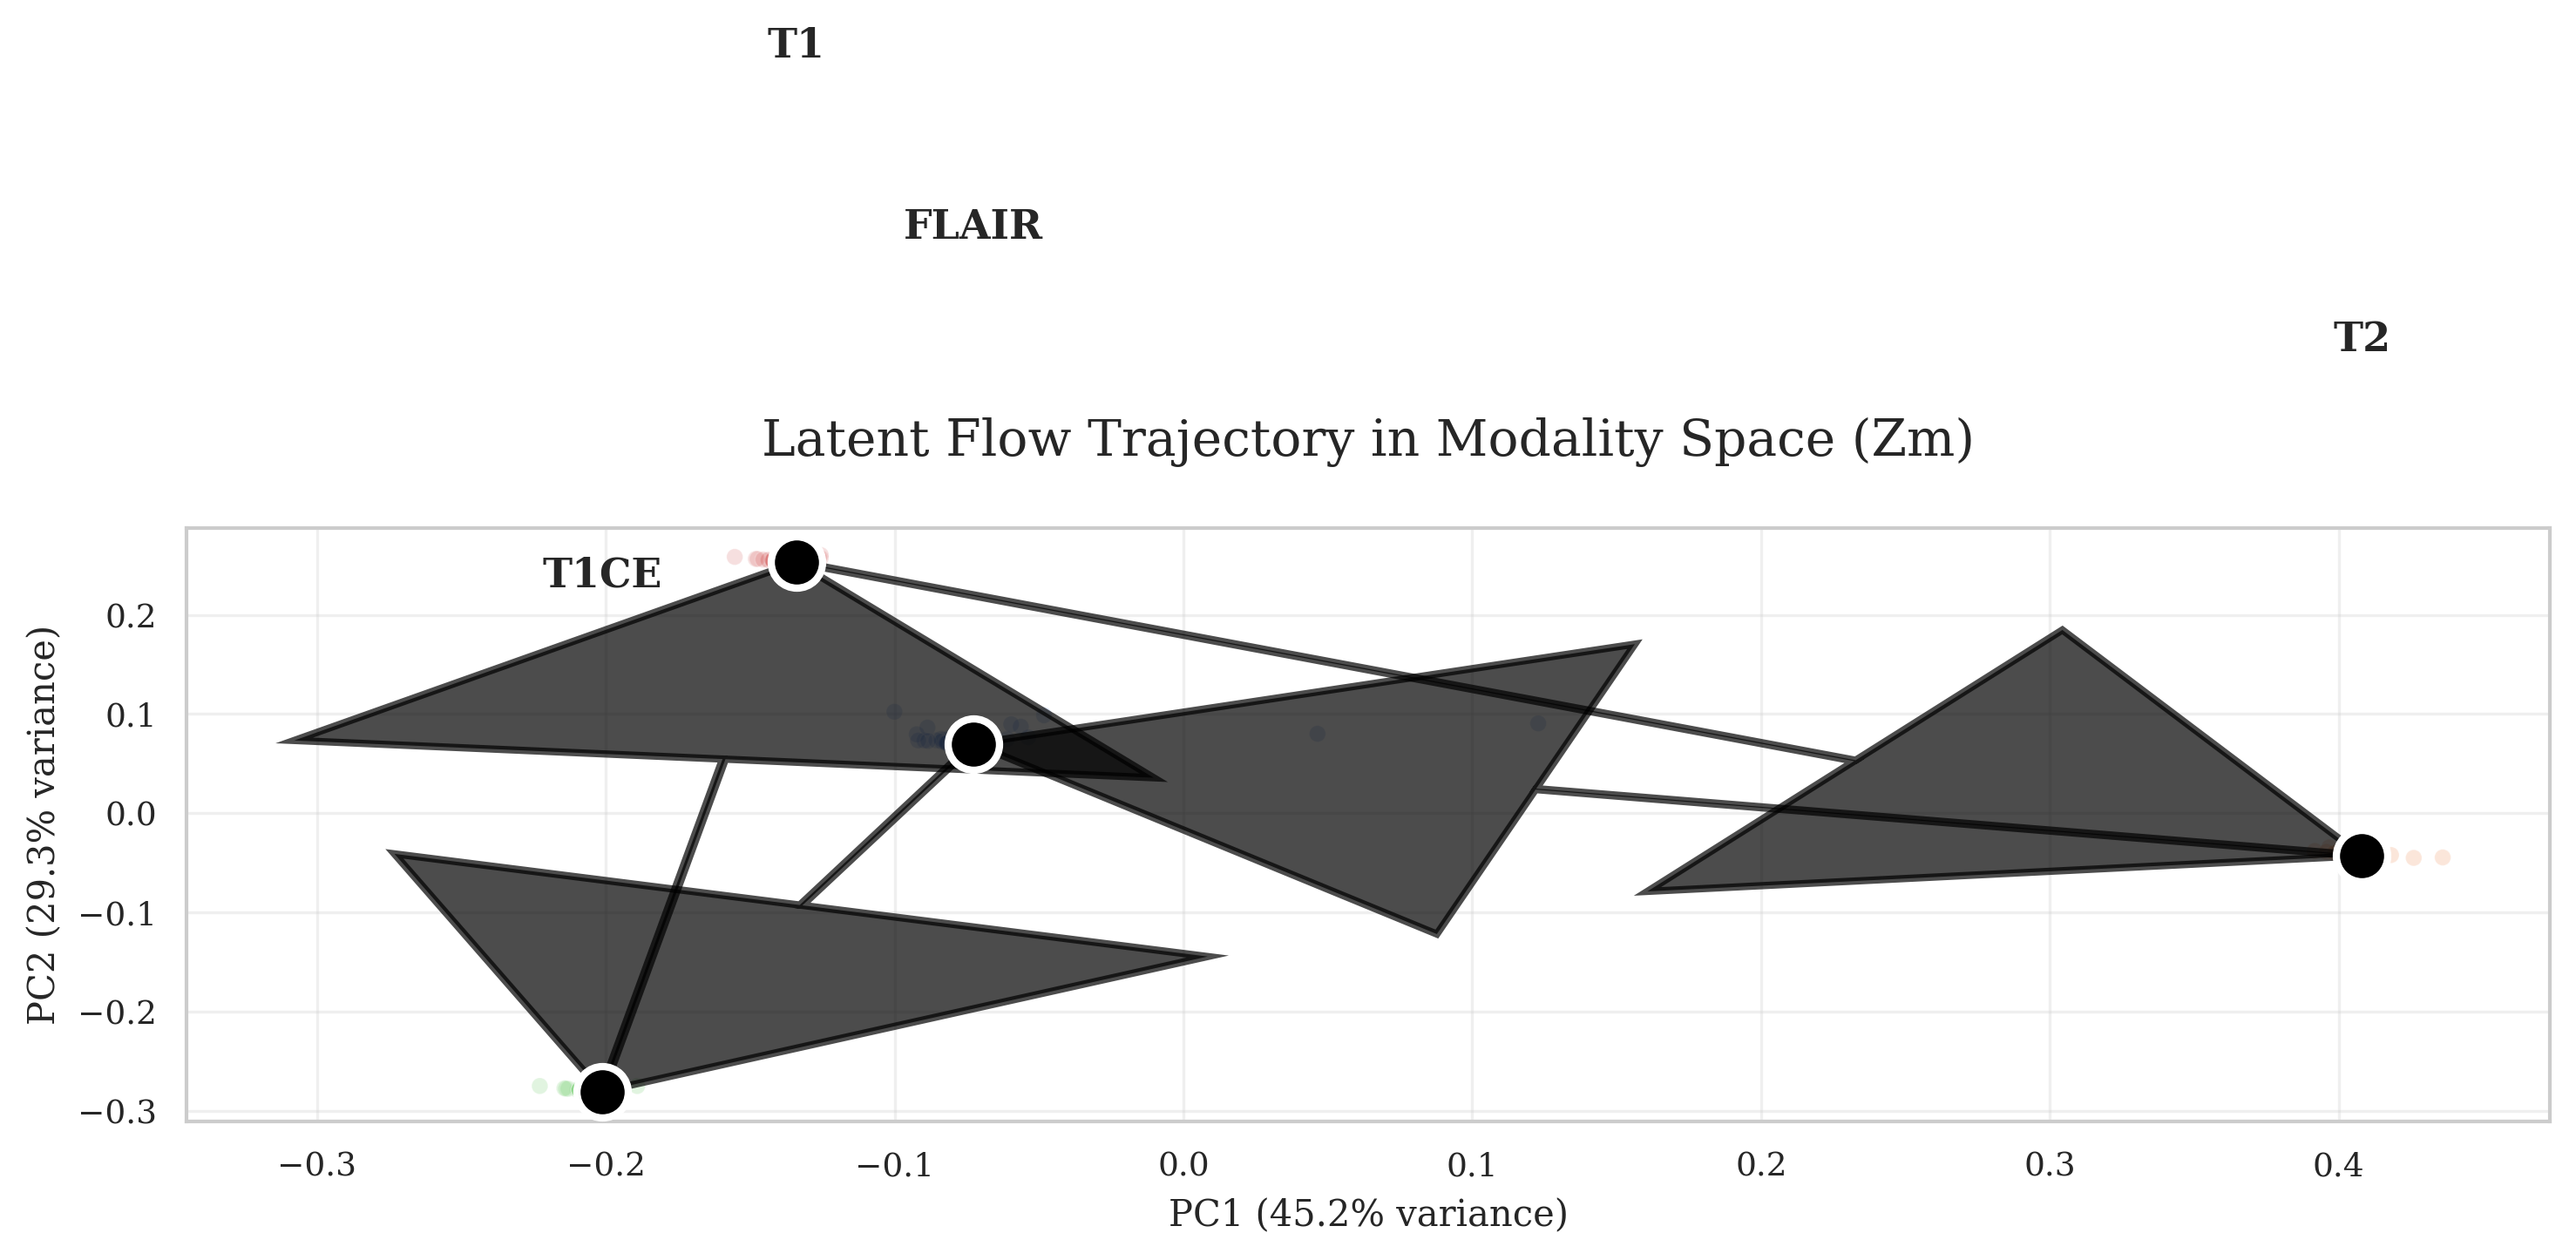

✓ Saved: 05_latent_flow_curves.png


In [25]:
# Compute centroid for each modality in Zm space
modality_centroids = {}
for mod in MODALITIES:
    mask = np.array([m == mod for m in all_modalities])
    modality_centroids[mod] = np.mean(all_zm[mask], axis=0)

# Project centroids to 2D
centroids_2d = pca.transform(np.array([modality_centroids[mod] for mod in MODALITIES]))

# Plot flow trajectory
plt.figure(figsize=(10, 8))

# Background: all points
sns.scatterplot(
    data=plot_df,
    x='PC1',
    y='PC2',
    hue='Modality',
    palette='muted',
    s=20,
    alpha=0.2,
    legend=False
)

# Flow trajectory
flow_order = ['t1', 't2', 'flair', 't1ce', 't1']  # Close the loop
flow_points = np.array([pca.transform(modality_centroids[mod].reshape(1, -1))[0] 
                        for mod in flow_order])

# Plot trajectory with arrows
for i in range(len(flow_order) - 1):
    start = flow_points[i]
    end = flow_points[i + 1]
    
    plt.arrow(
        start[0], start[1],
        end[0] - start[0], end[1] - start[1],
        head_width=0.3,
        head_length=0.2,
        fc='black',
        ec='black',
        linewidth=2,
        alpha=0.7,
        length_includes_head=True
    )

# Mark centroids
for i, mod in enumerate(flow_order[:-1]):
    plt.scatter(
        flow_points[i, 0],
        flow_points[i, 1],
        s=200,
        c='black',
        marker='o',
        edgecolor='white',
        linewidth=2,
        zorder=10
    )
    plt.text(
        flow_points[i, 0],
        flow_points[i, 1] + 0.5,
        MODALITY_NAMES[mod],
        ha='center',
        va='bottom',
        fontweight='bold',
        fontsize=11
    )

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('Latent Flow Trajectory in Modality Space (Zm)', fontsize=14, pad=20)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '05_latent_flow_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: 05_latent_flow_curves.png")

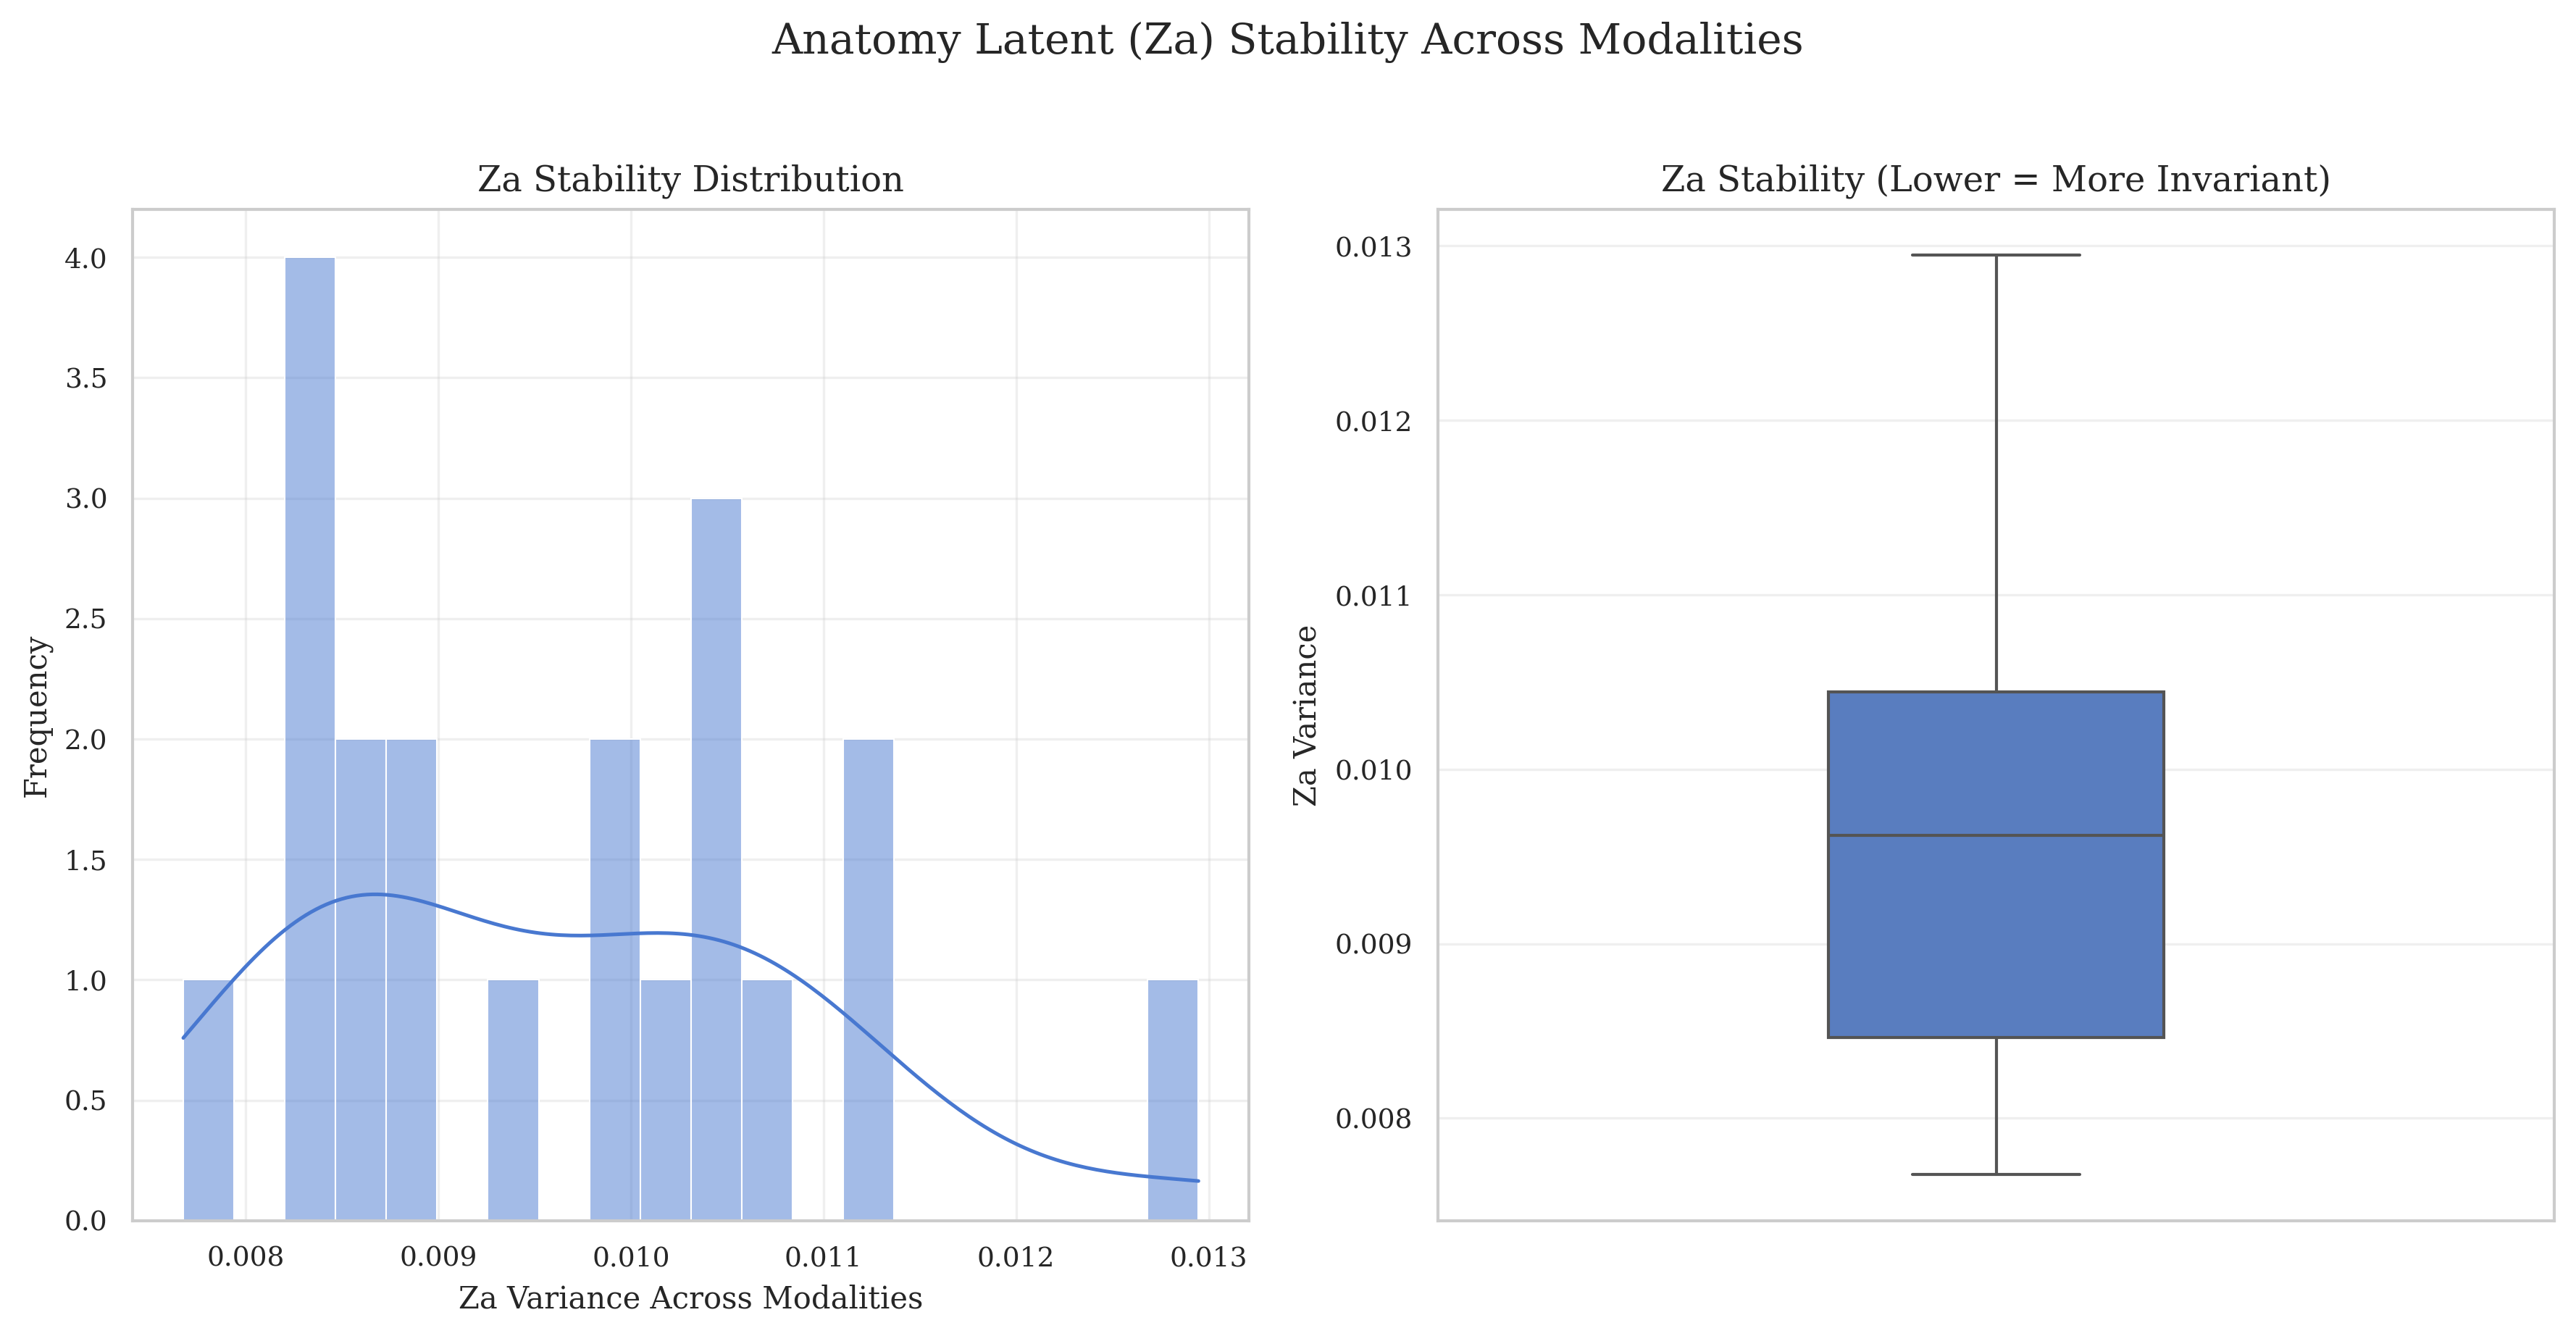

✓ Saved: 06_za_stability_surface.png

Za Stability Stats:
  Mean variance: 0.0096
  Std variance: 0.0013
  Min variance: 0.0077
  Max variance: 0.0129


In [26]:
# Compute Za variance for each patient across modalities
unique_patients = list(set(all_patients))
za_stability = []

for patient in unique_patients:
    patient_mask = np.array([p == patient for p in all_patients])
    patient_za = all_za[patient_mask]
    
    if len(patient_za) >= 2:  # Need at least 2 samples
        # Compute variance across modalities (lower = more stable)
        za_var = np.var(patient_za, axis=0).mean()
        za_stability.append({
            'patient': patient,
            'za_variance': za_var
        })

stability_df = pd.DataFrame(za_stability)

# Plot stability distribution
plt.figure(figsize=(12, 6))

# Histogram
plt.subplot(1, 2, 1)
sns.histplot(
    data=stability_df,
    x='za_variance',
    bins=20,
    kde=True,
    color=colors[0],
    edgecolor='white',
    linewidth=0.5
)
plt.xlabel('Za Variance Across Modalities')
plt.ylabel('Frequency')
plt.title('Za Stability Distribution')
plt.grid(True, alpha=0.3)

# Box plot
plt.subplot(1, 2, 2)
sns.boxplot(
    data=stability_df,
    y='za_variance',
    color=colors[0],
    width=0.3
)
plt.ylabel('Za Variance')
plt.title('Za Stability (Lower = More Invariant)')
plt.grid(True, alpha=0.3, axis='y')

plt.suptitle('Anatomy Latent (Za) Stability Across Modalities', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '06_za_stability_surface.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: 06_za_stability_surface.png")
print(f"\nZa Stability Stats:")
print(f"  Mean variance: {stability_df['za_variance'].mean():.4f}")
print(f"  Std variance: {stability_df['za_variance'].std():.4f}")
print(f"  Min variance: {stability_df['za_variance'].min():.4f}")
print(f"  Max variance: {stability_df['za_variance'].max():.4f}")

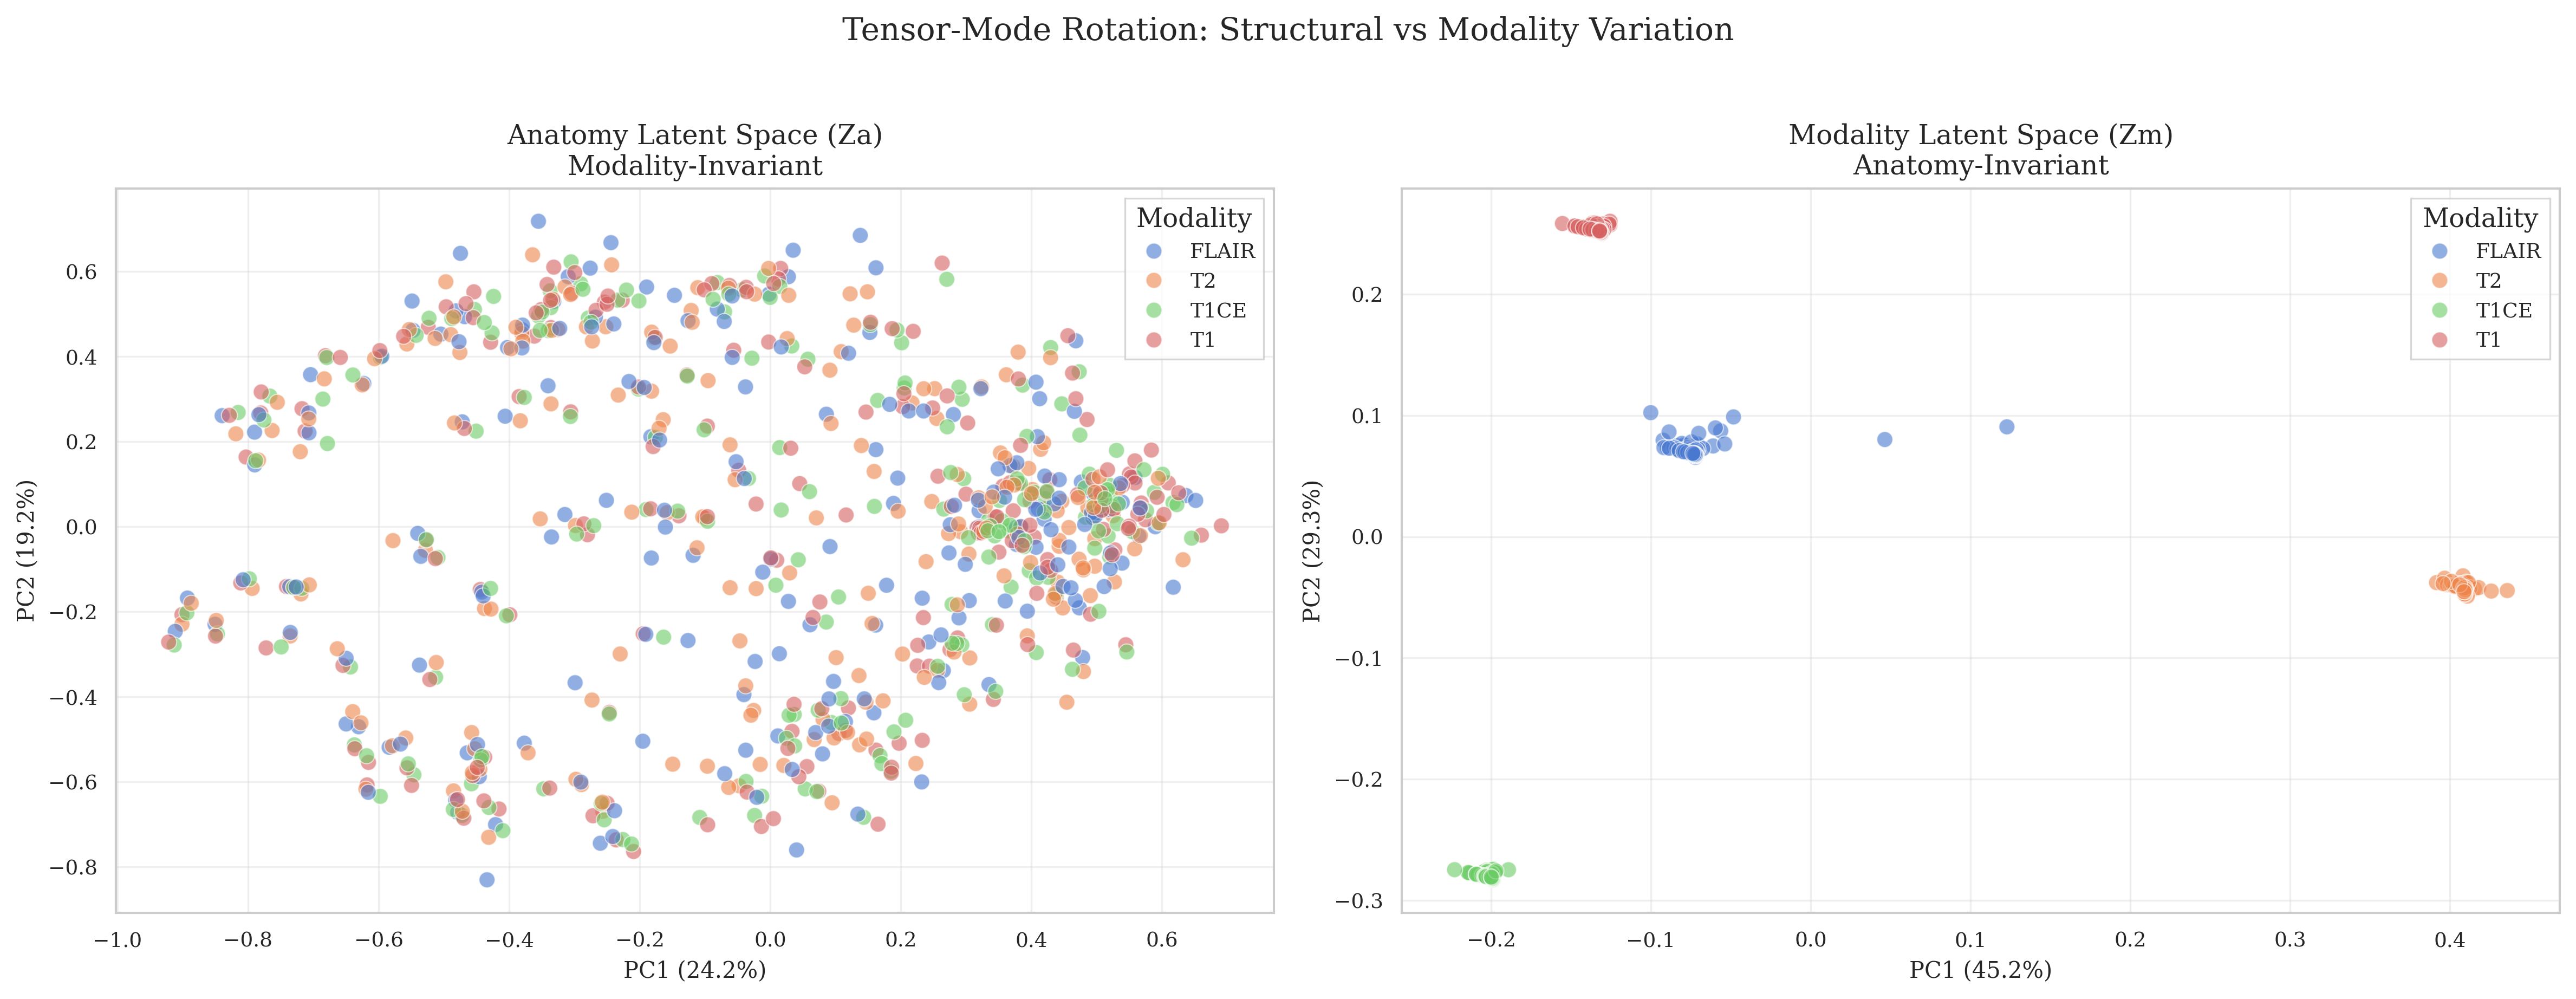

✓ Saved: 07_tensor_mode_rotation.png


In [27]:
# Perform PCA on both Za and Zm
pca_za = PCA(n_components=2)
za_2d = pca_za.fit_transform(all_za)

# Create side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Za (Anatomy - should cluster by patient, not modality)
za_df = pd.DataFrame({
    'PC1': za_2d[:, 0],
    'PC2': za_2d[:, 1],
    'Modality': [MODALITY_NAMES[m] for m in all_modalities]
})

sns.scatterplot(
    data=za_df,
    x='PC1',
    y='PC2',
    hue='Modality',
    palette='muted',
    s=50,
    alpha=0.6,
    ax=axes[0],
    edgecolor='white',
    linewidth=0.5
)
axes[0].set_xlabel(f'PC1 ({pca_za.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca_za.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title('Anatomy Latent Space (Za)\nModality-Invariant', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].legend(title='Modality', frameon=True, fancybox=False)

# Zm (Modality - should cluster by modality)
sns.scatterplot(
    data=plot_df,
    x='PC1',
    y='PC2',
    hue='Modality',
    palette='muted',
    s=50,
    alpha=0.6,
    ax=axes[1],
    edgecolor='white',
    linewidth=0.5
)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].set_title('Modality Latent Space (Zm)\nAnatomy-Invariant', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].legend(title='Modality', frameon=True, fancybox=False)

plt.suptitle('Tensor-Mode Rotation: Structural vs Modality Variation', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '07_tensor_mode_rotation.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: 07_tensor_mode_rotation.png")

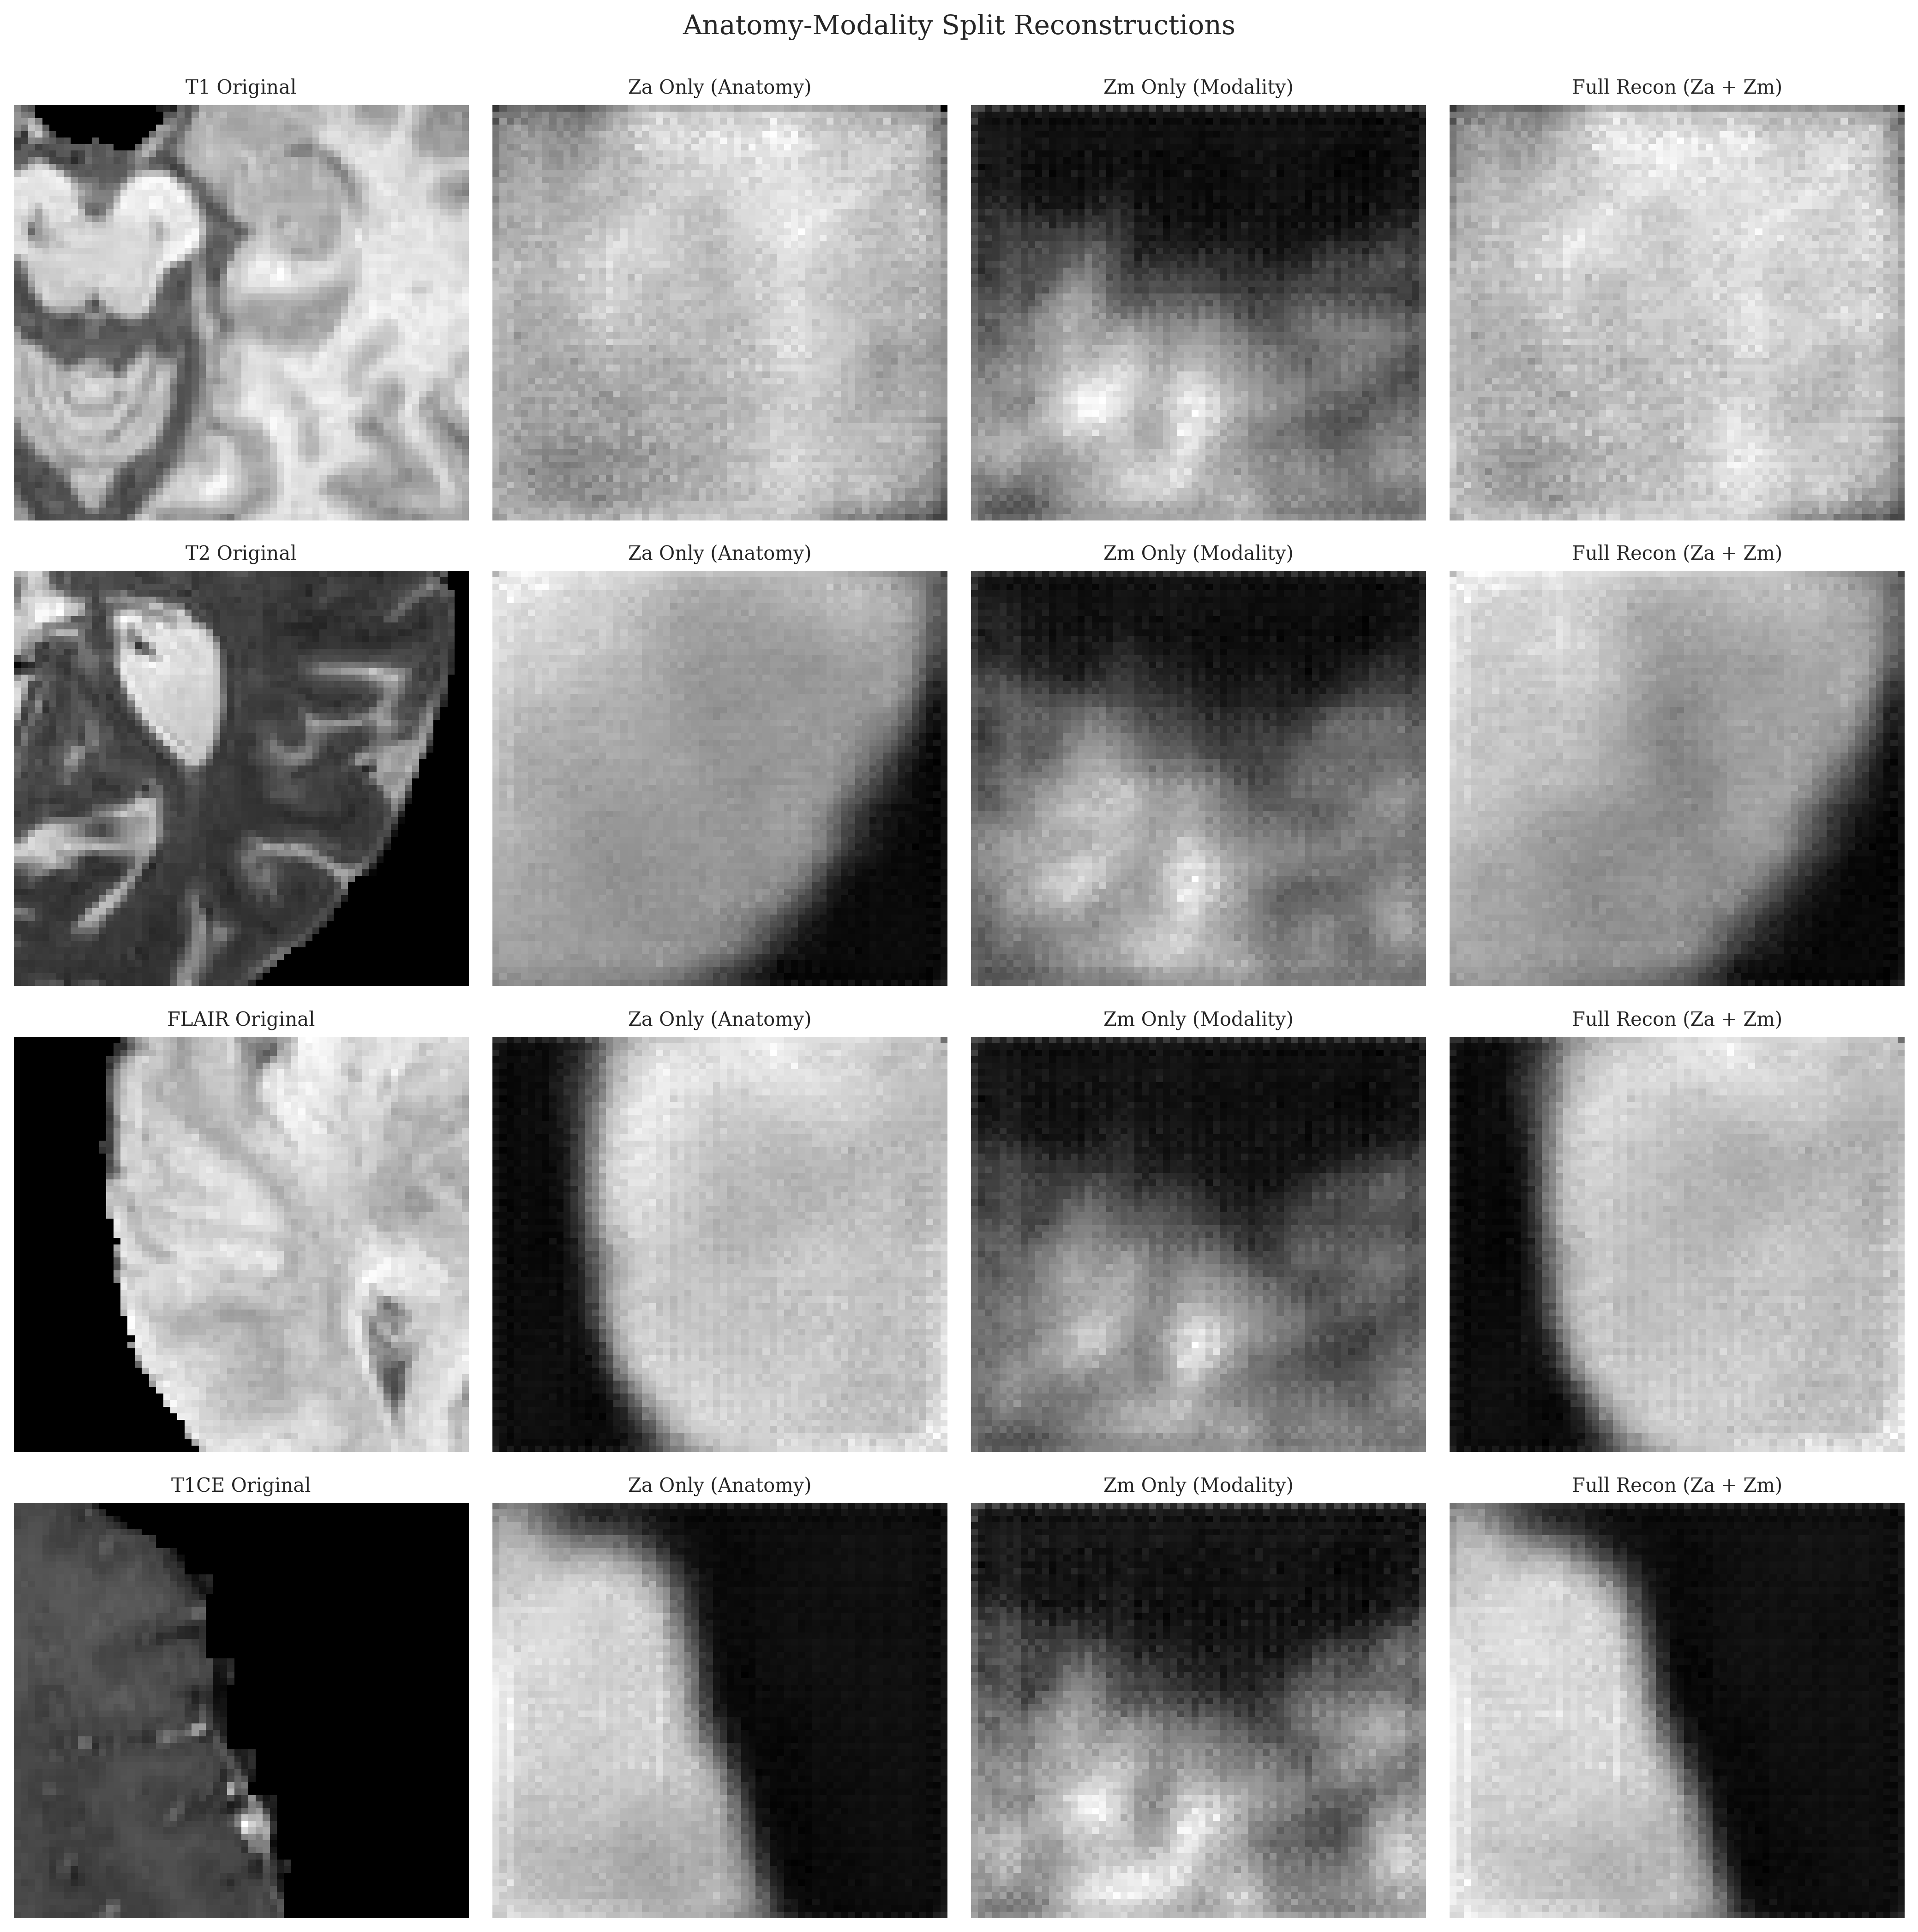

✓ Saved: 08_anatomy_modality_split.png


In [28]:
# Select one sample from each modality
sample_indices = [np.where(np.array(all_modalities) == mod)[0][0] for mod in MODALITIES]

# Generate reconstructions with different combinations
model.eval()
with torch.no_grad():
    fig, axes = plt.subplots(4, 4, figsize=(14, 14))
    
    for row, mod_idx in enumerate(sample_indices):
        # Get original patch
        original = all_originals[mod_idx, 0]  # (D, H, W)
        recon = all_reconstructions[mod_idx, 0]  # (D, H, W)
        
        # Get Za and Zm
        za = torch.FloatTensor(all_za[mod_idx]).unsqueeze(0).to(device)
        zm = torch.FloatTensor(all_zm[mod_idx]).unsqueeze(0).to(device)
        
        # Generate reconstructions
        recon_full = model.decoder(za, zm).cpu().numpy()[0, 0]
        recon_za_only = model.decoder(za, torch.zeros_like(zm)).cpu().numpy()[0, 0]
        recon_zm_only = model.decoder(torch.zeros_like(za), zm).cpu().numpy()[0, 0]
        
        # Plot central slices
        slice_idx = original.shape[-1] // 2
        
        # Original
        axes[row, 0].imshow(original[:, :, slice_idx].T, cmap='gray', aspect='auto')
        axes[row, 0].set_title(f'{MODALITY_NAMES[all_modalities[mod_idx]]} Original', fontsize=10)
        axes[row, 0].axis('off')
        
        # Za only (anatomy)
        axes[row, 1].imshow(recon_za_only[:, :, slice_idx].T, cmap='gray', aspect='auto')
        axes[row, 1].set_title('Za Only (Anatomy)', fontsize=10)
        axes[row, 1].axis('off')
        
        # Zm only (modality)
        axes[row, 2].imshow(recon_zm_only[:, :, slice_idx].T, cmap='gray', aspect='auto')
        axes[row, 2].set_title('Zm Only (Modality)', fontsize=10)
        axes[row, 2].axis('off')
        
        # Full reconstruction
        axes[row, 3].imshow(recon_full[:, :, slice_idx].T, cmap='gray', aspect='auto')
        axes[row, 3].set_title('Full Recon (Za + Zm)', fontsize=10)
        axes[row, 3].axis('off')
    
    plt.suptitle('Anatomy-Modality Split Reconstructions', fontsize=14, y=0.995)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / '08_anatomy_modality_split.png', dpi=300, bbox_inches='tight')
    plt.show()

print("✓ Saved: 08_anatomy_modality_split.png")

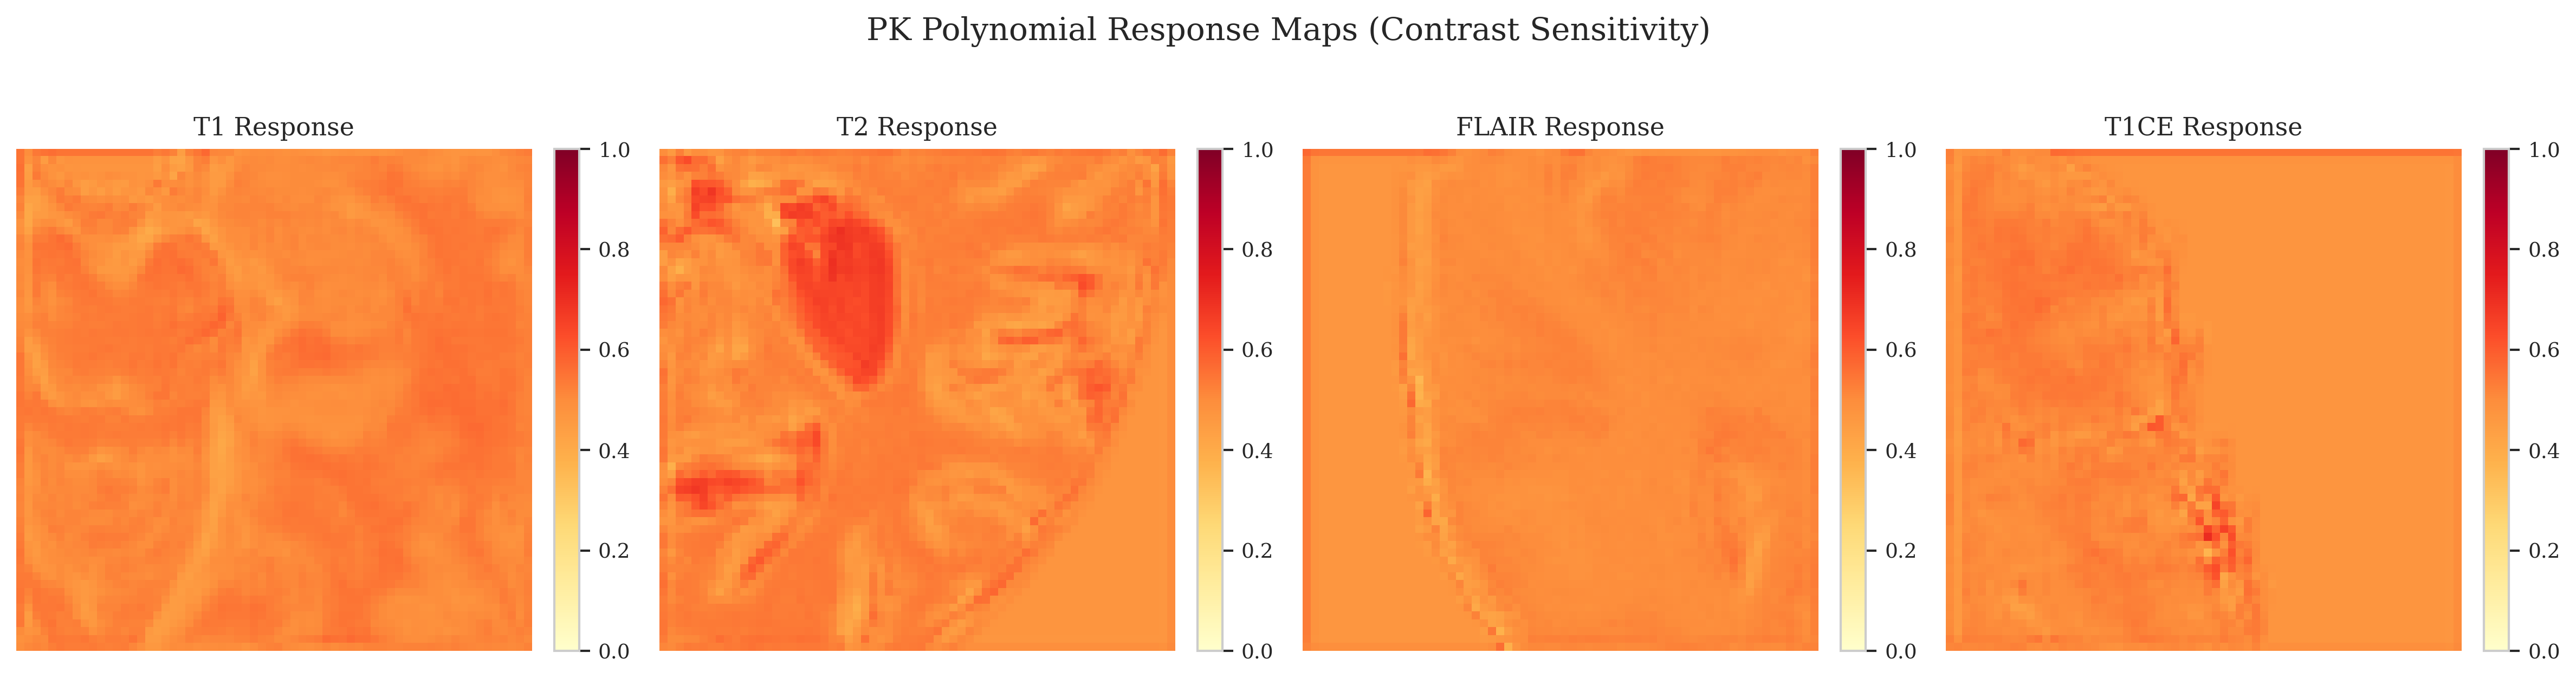

✓ Saved: 09_pk_polynomial_response.png


In [29]:
# Plot polynomial response maps for each modality
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for idx, (ax, mod_idx) in enumerate(zip(axes, sample_indices)):
    # Get response map
    response = all_responses[mod_idx, 0]  # (D, H, W)
    
    # Take central slice
    slice_idx = response.shape[-1] // 2
    response_slice = response[:, :, slice_idx]
    
    # Plot as heatmap
    im = ax.imshow(response_slice.T, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
    ax.set_title(f'{MODALITY_NAMES[all_modalities[mod_idx]]} Response', fontsize=11)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('PK Polynomial Response Maps (Contrast Sensitivity)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '09_pk_polynomial_response.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: 09_pk_polynomial_response.png")

In [30]:
# Compute summary statistics
summary_stats = {
    'Total Samples': len(all_za),
    'Za Dimension': LATENT_DIM_ZA,
    'Zm Dimension': LATENT_DIM_ZM,
    'Za Mean Variance': stability_df['za_variance'].mean(),
    'Za Std Variance': stability_df['za_variance'].std(),
    'Final Reconstruction Loss': history['recon_loss'][-1],
    'Final Anatomy Invariance Loss': history['anatomy_inv_loss'][-1],
    'Final Modality Discrimination Loss': history['modality_disc_loss'][-1],
    'Final Orthogonality Loss': history['ortho_loss'][-1]
}

summary_df = pd.DataFrame([summary_stats])
summary_df.to_csv(OUTPUT_DIR / 'summary_statistics.csv', index=False)

print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)
for key, value in summary_stats.items():
    if isinstance(value, float):
        print(f"{key:.<50} {value:.6f}")
    else:
        print(f"{key:.<50} {value}")
print("="*80)

print("\n✓ Saved: summary_statistics.csv")


SUMMARY STATISTICS
Total Samples..................................... 800
Za Dimension...................................... 64
Zm Dimension...................................... 32
Za Mean Variance.................................. 0.009633869864046574
Za Std Variance................................... 0.0013351688394322991
Final Reconstruction Loss......................... 0.538666
Final Anatomy Invariance Loss..................... 0.010801
Final Modality Discrimination Loss................ 0.000665
Final Orthogonality Loss.......................... 0.000052

✓ Saved: summary_statistics.csv
